# Shishaldin: build catalog + waveforms, then compare filtered vs. denoised


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from obspy import UTCDateTime, Stream
from obspy.clients.fdsn import Client
from obspy.signal.trigger import recursive_sta_lta, trigger_onset
import seisbench.models as sbm

In [116]:
# params

SOURCE = "IRIS"
NETWORK = "AV"
STATION = "SSLS"
LOCATION = ""
CHANNEL = "BH*"

# interested in last minute, start a minute before for sta/lta START_UP SECONDS
### want to find a way to only go through about 8-24 hours at a time for the whole week, then bring it all together for the sake of well,
### i don't really know but computah is working overtime doing this all at once (for loop)
START_TIME = UTCDateTime("2025-11-01T00:00:00")
STOP_TIME = UTCDateTime("2025-11-02T00:00:00")

# padding on each side of the analysis window, trimmed off after
# filtering to remove taper/edge effects
EDGE_TRIM_SECONDS = 5

# params for filtering (bandpass)
FREQMIN = 0.9
FREQMAX = 8.0
CORNERS = 2

# sta/lta parameters
# try to make STARTUP_SECONDS = or > LTA_SECONDS so it has enough time
STA_SECONDS = 1.5
LTA_SECONDS = 15.0
TRIGGER_ON = 2.0
TRIGGER_OFF = 1.0
STARTUP_SECONDS = 120

In [117]:
# load client to get data and model

client = Client(SOURCE)

inv = client.get_stations(
    network=NETWORK,
    station=STATION,
    level="response"
)

model = sbm.DeepDenoiser.from_pretrained("original")

/Users/amelega/miniconda3/envs/deepdenoiser/lib/python3.8/site-packages/seisbench/models/base.py:527: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.loa

In [118]:
# download the whole analysis window in a single request
# (padded on both sides so filtering/tapering doesn't distort the
# edges of the window we actually care about)

download_start = START_TIME - EDGE_TRIM_SECONDS
download_end = STOP_TIME + EDGE_TRIM_SECONDS

stream = client.get_waveforms(
    NETWORK,
    STATION,
    LOCATION,
    CHANNEL,
    download_start,
    download_end
)

# remove instrument response
stream.remove_response(
    inventory=inv,
    output="VEL"
)

raw_trace = stream.select(channel="BHZ")[0].copy()
raw_trace.trim(starttime=START_TIME, endtime=STOP_TIME)

print(raw_trace)

AV.SSLS..BHZ | 2025-11-01T00:00:00.000000Z - 2025-11-02T00:00:00.000000Z | 50.0 Hz, 4320001 samples


In [119]:
# filter the full trace once

filtered_full_trace = stream.select(channel="BHZ")[0].copy()

filtered_full_trace.detrend("demean")
filtered_full_trace.detrend("linear")

# filtered_full_trace.taper(max_percentage=0.03)

filtered_full_trace.filter("bandpass", freqmin=FREQMIN, freqmax=FREQMAX, corners=CORNERS, zerophase=True)

# drop the padding now that filtering/tapering is done
filtered_full_trace.trim(starttime=START_TIME, endtime=STOP_TIME)

# want to be 30 minutes
print(filtered_full_trace)

AV.SSLS..BHZ | 2025-11-01T00:00:00.000000Z - 2025-11-02T00:00:00.000000Z | 50.0 Hz, 4320001 samples


In [120]:
# run DeepDenoiser once on the full continuous filtered trace

denoised_stream = Stream([filtered_full_trace])
denoised_full = model.annotate(denoised_stream)
denoised_full_trace = denoised_full[0].copy()

# DeepDenoiser resamples internally (commonly to 100 Hz), so the denoised
# trace usually comes back at a different rate than filtered_full_trace.
# Bring it back down/up to match -- SNR/SDR comparisons downstream (Part 2)
# require the filtered and denoised traces to share a sampling rate, and
# compute_event_metrics() in shishaldin_snr_diagnostics.py raises a
# ValueError if they don't.
if denoised_full_trace.stats.sampling_rate != filtered_full_trace.stats.sampling_rate:
    print(f"Resampling denoised trace: {denoised_full_trace.stats.sampling_rate} Hz "
          f"-> {filtered_full_trace.stats.sampling_rate} Hz (to match filtered trace)")
    denoised_full_trace.resample(filtered_full_trace.stats.sampling_rate)

# notice upsampling
print(denoised_full_trace)

Resampling denoised trace: 100.0 Hz -> 50.0 Hz (to match filtered trace)
AV.SSLS..DeepDenoiser_BHZ | 2025-11-01T00:00:00.000000Z - 2025-11-02T00:00:00.000000Z | 50.0 Hz, 4320001 samples


In [121]:
# sta/lta function

def run_sta_lta(trace, sta_seconds=STA_SECONDS, lta_seconds=LTA_SECONDS, trigger_on=TRIGGER_ON, trigger_off=TRIGGER_OFF, startup_seconds=STARTUP_SECONDS):

    fs = trace.stats.sampling_rate
    nsta = int(sta_seconds * fs)
    nlta = int(lta_seconds * fs)

    cft = recursive_sta_lta(trace.data, nsta, nlta)

    # no triggers during startup period because they were bad
    startup_samples = int(startup_seconds * fs)

    cft_for_trigger = cft.copy()
    cft_for_trigger[:startup_samples] = 0
    triggers = trigger_onset(cft_for_trigger, trigger_on, trigger_off)

    return cft, triggers

In [122]:
# run STA/LTA on the continuous filtered and denoised traces

cft_filtered, triggers_filtered = run_sta_lta(filtered_full_trace)
cft_filtered_denoised, triggers_filtered_denoised = run_sta_lta(denoised_full_trace)

n_events_filtered = len(triggers_filtered)
n_events_filtered_denoised = len(triggers_filtered_denoised)

print(f"any NaNs (filtered): {np.isnan(cft_filtered).any()}")
print(f"any NaNs (denoised): {np.isnan(cft_filtered_denoised).any()}")
print(f"number of events in filtered data: {n_events_filtered}")
print(f"number of events in denoised data: {n_events_filtered_denoised}")

any NaNs (filtered): False
any NaNs (denoised): False
number of events in filtered data: 1599
number of events in denoised data: 1347


In [123]:
# whole-period SNR

def calculate_whole_period_snr(trace, triggers):

    data = trace.data.astype(float)

    signal_mask = np.zeros(len(data), dtype=bool)

    for on, off in triggers:
        signal_mask[on:off] = True

    signal_data = data[signal_mask]

    # better ways to calculate noise?
    noise_data = data[~signal_mask]

    if len(signal_data) == 0 or len(noise_data) == 0:
        return np.nan, np.nan, np.nan

    signal_rms = np.sqrt(np.mean(signal_data ** 2))
    noise_rms = np.sqrt(np.mean(noise_data ** 2))

    if noise_rms == 0:
        snr_db = np.nan
    else:
        snr_db = 20 * np.log10(signal_rms / noise_rms)

    return signal_rms, noise_rms, snr_db


filtered_signal_rms, filtered_noise_rms, filtered_snr_db = (calculate_whole_period_snr(filtered_full_trace, triggers_filtered))

denoised_signal_rms, denoised_noise_rms, denoised_snr_db = (calculate_whole_period_snr(denoised_full_trace, triggers_filtered_denoised))

print("WHOLE-PERIOD SNR")
print("Filtered:")
print(f"  Signal RMS: {filtered_signal_rms:.6e}")
print(f"  Noise RMS:  {filtered_noise_rms:.6e}")
print(f"  SNR:        {filtered_snr_db:.2f} dB")
print()
print("Denoised:")
print(f"  Signal RMS: {denoised_signal_rms:.6e}")
print(f"  Noise RMS:  {denoised_noise_rms:.6e}")
print(f"  SNR:        {denoised_snr_db:.2f} dB")

WHOLE-PERIOD SNR
Filtered:
  Signal RMS: 9.150246e-07
  Noise RMS:  3.506976e-07
  SNR:        8.33 dB

Denoised:
  Signal RMS: 2.273736e-07
  Noise RMS:  3.387100e-08
  SNR:        16.54 dB


## Build catalog for events

In [124]:
# build a long-format event catalog: one row per DETECTION (filtered or denoised).
# events found in both traces share the same event_number; events found in only
# one trace still get their own row/event_number instead of being dropped

def get_window_metrics(trace, window_start, window_end):
    event = trace.copy()
    event.trim(starttime=window_start, endtime=window_end)

    signal_data = event.data.astype(float)
    signal_rms = np.sqrt(np.mean(signal_data ** 2))
    max_amplitude = np.max(np.abs(signal_data))

    noise_duration = LTA_SECONDS
    noise_end = window_start
    noise_start = noise_end - noise_duration

    noise = trace.copy()
    noise.trim(starttime=noise_start, endtime=noise_end)

    if len(noise.data) > 0:
        noise_data = noise.data.astype(float)
        noise_rms = np.sqrt(np.mean(noise_data ** 2))
        snr = (
            20 * np.log10(signal_rms / noise_rms)
            if noise_rms > 0 else np.nan
        )
    else:
        noise_rms, snr = np.nan, np.nan

    return signal_rms, noise_rms, snr, max_amplitude


def triggers_to_intervals(trace, triggers):
    intervals = []
    for on, off in triggers:
        start = trace.stats.starttime + on / trace.stats.sampling_rate
        end = trace.stats.starttime + off / trace.stats.sampling_rate
        intervals.append((start, end))
    return intervals


def intervals_overlap(a_start, a_end, b_start, b_end):
    return a_start < b_end and b_start < a_end


filtered_intervals = triggers_to_intervals(filtered_full_trace, triggers_filtered)
denoised_intervals = triggers_to_intervals(denoised_full_trace, triggers_filtered_denoised)

# assign event numbers: filtered detections are numbered first, in order.
# a denoised detection that overlaps a filtered one gets that SAME event_number.
# any denoised detection left over (no overlap) gets its own new event_number.
event_number = 0
matched_denoised_idx = set()
rows = []

for f_start, f_end in filtered_intervals:
    event_number += 1

    signal_rms, noise_rms, snr_db, max_amplitude = get_window_metrics(
        filtered_full_trace, f_start, f_end
    )

    rows.append({
        "event_number": event_number,
        "detection_type": "filtered",
        "start_time": f_start.strftime("%Y-%m-%dT%H:%M:%S.%f"),
        "end_time": f_end.strftime("%Y-%m-%dT%H:%M:%S.%f"),
        "duration_seconds": float(f_end - f_start),
        "signal_rms": float(signal_rms),
        "noise_rms": float(noise_rms),
        "snr_db": float(snr_db),
        "max_amplitude": float(max_amplitude),
    })

    # look for a denoised detection overlapping this filtered one (first match)
    for d_idx, (d_start, d_end) in enumerate(denoised_intervals):
        if d_idx in matched_denoised_idx:
            continue
        if intervals_overlap(f_start, f_end, d_start, d_end):
            matched_denoised_idx.add(d_idx)

            d_signal_rms, d_noise_rms, d_snr_db, d_max_amplitude = get_window_metrics(
                denoised_full_trace, d_start, d_end
            )

            rows.append({
                "event_number": event_number,
                "detection_type": "denoised",
                "start_time": d_start.strftime("%Y-%m-%dT%H:%M:%S.%f"),
                "end_time": d_end.strftime("%Y-%m-%dT%H:%M:%S.%f"),
                "duration_seconds": float(d_end - d_start),
                "signal_rms": float(d_signal_rms),
                "noise_rms": float(d_noise_rms),
                "snr_db": float(d_snr_db),
                "max_amplitude": float(d_max_amplitude),
            })
            break

# any denoised detections that never matched a filtered one get new event numbers
for d_idx, (d_start, d_end) in enumerate(denoised_intervals):
    if d_idx in matched_denoised_idx:
        continue

    event_number += 1

    signal_rms, noise_rms, snr_db, max_amplitude = get_window_metrics(
        denoised_full_trace, d_start, d_end
    )

    rows.append({
        "event_number": event_number,
        "detection_type": "denoised",
        "start_time": d_start.strftime("%Y-%m-%dT%H:%M:%S.%f"),
        "end_time": d_end.strftime("%Y-%m-%dT%H:%M:%S.%f"),
        "duration_seconds": float(d_end - d_start),
        "signal_rms": float(signal_rms),
        "noise_rms": float(noise_rms),
        "snr_db": float(snr_db),
        "max_amplitude": float(max_amplitude),
    })

event_results = pd.DataFrame(rows).sort_values(["event_number", "detection_type"]).reset_index(drop=True)

def format_float(x):
    if pd.isna(x):
        return ""

    x = float(x)

    if x == 0:
        return "0.00"

    exponent = int(np.floor(np.log10(abs(x))))

    if exponent >= 3 or exponent <= -3:
        return f"{x:.2e}"
    else:
        return f"{x:.2f}"

event_results_csv = event_results.copy()
numeric_columns = event_results_csv.select_dtypes(include="number").columns.drop("event_number", errors="ignore")

for col in numeric_columns:
    event_results_csv[col] = event_results_csv[col].map(format_float)

event_results_csv["event_number"] = event_results_csv["event_number"].astype(int)

# save csv
event_results_csv.to_csv("shishaldin_catalog_1_week.csv", index=False)

n_matched = len(matched_denoised_idx)
n_filtered_only = len(filtered_intervals) - n_matched
n_denoised_only = len(denoised_intervals) - n_matched

print(f"filtered detections: {len(filtered_intervals)}")
print(f"denoised detections: {len(denoised_intervals)}")
print(f"matched (same event_number in both): {n_matched}")
print(f"filtered-only events: {n_filtered_only}")
print(f"denoised-only events: {n_denoised_only}")
print(f"total rows saved: {len(event_results)}")

event_results.head(10)

filtered detections: 1599
denoised detections: 1347
matched (same event_number in both): 1156
filtered-only events: 443
denoised-only events: 191
total rows saved: 2946


,event_number,detection_type,start_time,end_time,duration_seconds,signal_rms,noise_rms,snr_db,max_amplitude
0,1,denoised,2025-11-01T00:02:14.320000,2025-11-01T00:02:27.260000,12.94,3.349820e-09,6.959208e-10,13.649234,1.103788e-08
1,1,filtered,2025-11-01T00:02:15.680000,2025-11-01T00:02:24.360000,8.68,7.568509e-08,3.938544e-08,5.673493,1.997267e-07
2,2,denoised,2025-11-01T00:02:35.440000,2025-11-01T00:02:49.240000,13.80,7.046450e-08,3.593172e-09,25.849848,2.840516e-07
3,2,filtered,2025-11-01T00:02:41.200000,2025-11-01T00:02:51.040000,9.84,2.237853e-07,4.809938e-08,13.353841,7.858274e-07
4,3,filtered,2025-11-01T00:04:08.160000,2025-11-01T00:04:12.680000,4.52,6.808597e-08,5.466768e-08,1.906539,2.026127e-07
5,4,denoised,2025-11-01T00:04:18.740000,2025-11-01T00:04:31.120000,12.38,5.922580e-08,2.724022e-09,26.746007,2.046035e-07
6,4,filtered,2025-11-01T00:04:19.100000,2025-11-01T00:04:28.500000,9.40,2.203937e-07,6.589408e-08,10.487054,6.528078e-07
7,5,filtered,2025-11-01T00:04:39.580000,2025-11-01T00:04:43.200000,3.62,1.420617e-07,1.314192e-07,0.676366,3.890111e-07
8,6,denoised,2025-11-01T00:05:12.400000,2025-11-01T00:05:25.260000,12.86,9.750286e-08,1.044612e-08,19.401245,3.015014e-07
9,6,filtered,2025-11-01T00:05:12.920000,2025-11-01T00:05:24.240000,11.32,4.228664e-07,1.045462e-07,12.137896,1.175833e-06


### Plots
#### First plot is raw/filtered/denoised

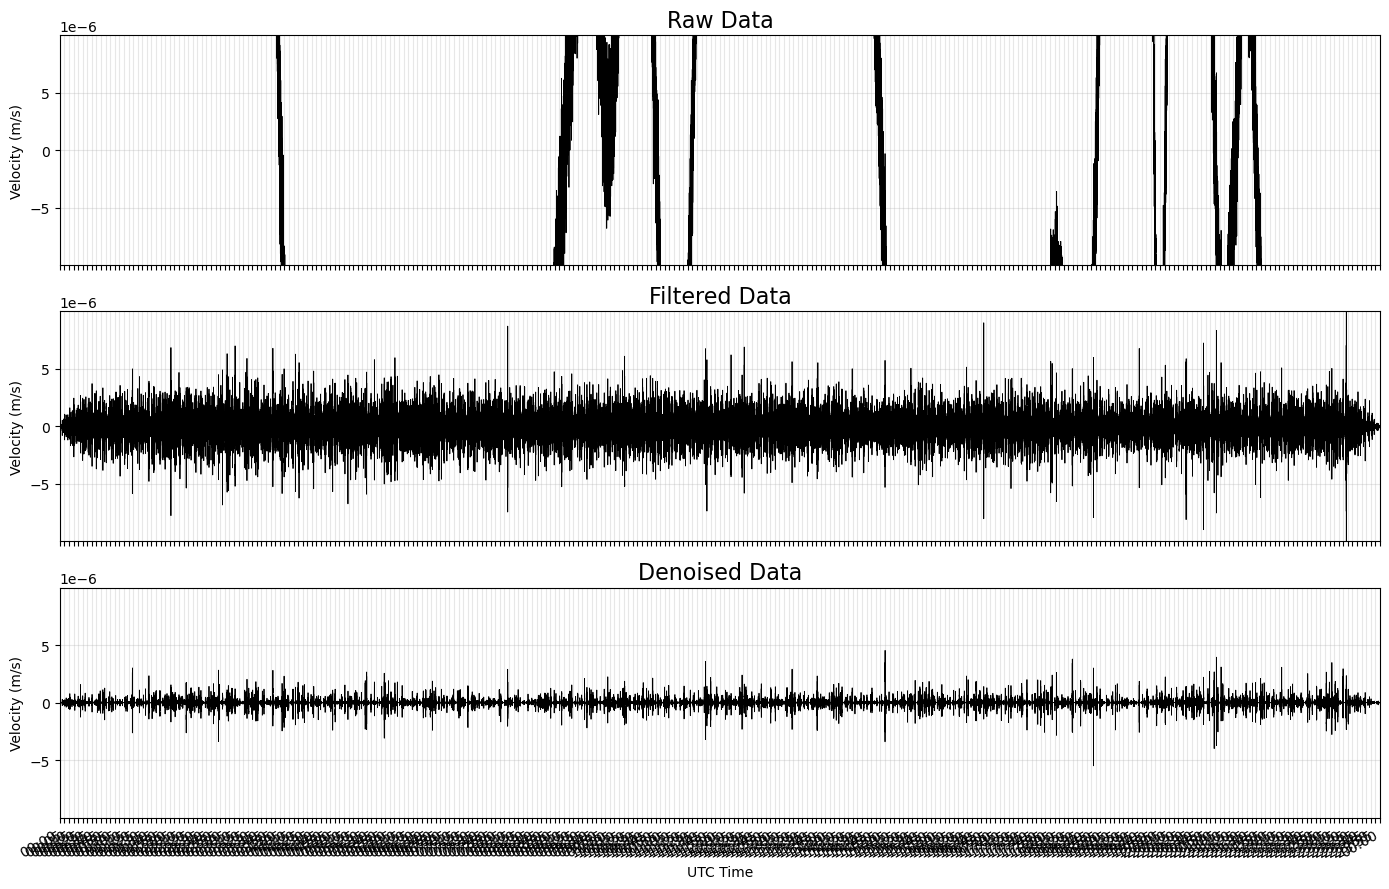

In [125]:
# plot raw / filtered / denoised waveforms

times_raw = raw_trace.times("matplotlib")
times_filtered = filtered_full_trace.times("matplotlib")
times_denoised = denoised_full_trace.times("matplotlib")

waveform_ylim = (-10e-6, 10e-6)
waveform_yticks = [-5e-6, 0, 5e-6]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(times_raw, raw_trace.data, linewidth=0.6, color="black")
axes[0].set_title("Raw Data", fontsize=16)
axes[0].set_ylabel("Velocity (m/s)")
axes[0].set_ylim(waveform_ylim)
axes[0].set_yticks(waveform_yticks)
axes[0].ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
axes[0].grid(True, alpha=0.3)

axes[1].plot(times_filtered, filtered_full_trace.data, linewidth=0.6, color="black")
axes[1].set_title("Filtered Data", fontsize=16)
axes[1].set_ylabel("Velocity (m/s)")
axes[1].set_ylim(waveform_ylim)
axes[1].set_yticks(waveform_yticks)
axes[1].ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
axes[1].grid(True, alpha=0.3)

axes[2].plot(times_denoised, denoised_full_trace.data, linewidth=0.6, color="black")
axes[2].set_title("Denoised Data", fontsize=16)
axes[2].set_ylabel("Velocity (m/s)")
axes[2].set_xlabel("UTC Time")
axes[2].set_ylim(waveform_ylim)
axes[2].set_yticks(waveform_yticks)
axes[2].ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.margins(x=0)
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Filtered vs. Denosied with sta/lta triggers

In [126]:
# # plot filtered vs denoised waveforms with STA/LTA triggers

# times_filtered = filtered_full_trace.times("matplotlib")
# times_filtered_denoised = denoised_full_trace.times("matplotlib")

# waveform_ylim = (-10e-6, 10e-6)
# waveform_yticks = [-5e-6, 0, 5e-6]

# fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex="col")

# ax = axes[0, 0]
# ax.plot(times_filtered, filtered_full_trace.data, linewidth=0.8, color="black")
# ax.set_title("Filtered", fontsize=18)
# ax.set_ylabel("Velocity (m/s)")
# ax.set_yticks(waveform_yticks)
# ax.set_ylim(waveform_ylim)
# ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))

# for i, (on, off) in enumerate(triggers_filtered):
#     ax.axvline(times_filtered[on], color="red", linewidth=2, alpha=0.9,
#                label="Trigger On" if i == 0 else None)
#     ax.axvline(times_filtered[off], color="blue", linewidth=2, alpha=0.9,
#                label="Trigger Off" if i == 0 else None)

# ax.legend(loc="lower right")
# ax.grid(True, alpha=0.3)

# ax = axes[0, 1]
# ax.plot(times_filtered_denoised, denoised_full_trace.data, linewidth=0.8, color="black")
# ax.set_title("Denoised", fontsize=18)
# ax.set_ylabel("Velocity (m/s)")
# ax.set_yticks(waveform_yticks)
# ax.set_ylim(waveform_ylim)
# ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))

# for i, (on, off) in enumerate(triggers_filtered_denoised):
#     ax.axvline(times_filtered_denoised[on], color="red", linewidth=2, alpha=0.8,
#                label="Trigger On" if i == 0 else None)
#     ax.axvline(times_filtered_denoised[off], color="blue", linewidth=2, alpha=0.8,
#                label="Trigger Off" if i == 0 else None)

# ax.legend(loc="lower right")
# ax.grid(True, alpha=0.3)

# ax = axes[1, 0]
# ax.plot(times_filtered, cft_filtered, linewidth=0.8, color="black")
# ax.axhline(TRIGGER_ON, color="red", linestyle="--", linewidth=1.5, label="Trigger On")
# ax.axhline(TRIGGER_OFF, color="blue", linestyle="--", linewidth=1.5, label="Trigger Off")
# ax.set_ylabel("STA/LTA")
# ax.set_xlabel("UTC Time")
# ax.set_title("Filtered STA/LTA")
# ax.legend()
# ax.grid(True, alpha=0.3)

# ax = axes[1, 1]
# ax.plot(times_filtered_denoised, cft_filtered_denoised, linewidth=0.8, color="black")
# ax.axhline(TRIGGER_ON, color="red", linestyle="--", linewidth=1.5, label="Trigger On")
# ax.axhline(TRIGGER_OFF, color="blue", linestyle="--", linewidth=1.5, label="Trigger Off")
# ax.set_ylabel("STA/LTA")
# ax.set_xlabel("UTC Time")
# ax.set_title("Denoised STA/LTA")
# ax.legend()
# ax.grid(True, alpha=0.3)

# for ax in axes.flat:
#     ax.margins(x=0)
#     ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
#     ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

# fig.autofmt_xdate()
# plt.tight_layout()
# plt.show()

### same plot as above but with shaded events for overlaps between filtered and denoised detections

In [127]:
# # plot filtered vs denoised waveforms with STA/LTA triggers,
# # shaded by whether the event overlaps between filtered and denoised detections

# def to_mpl(t):
#     return t.matplotlib_date

# def intervals_overlap(a_start, a_end, b_start, b_end):
#     return a_start < b_end and b_start < a_end

# # convert triggers to UTCDateTime intervals
# filtered_intervals = [
#     (filtered_full_trace.stats.starttime + on / filtered_full_trace.stats.sampling_rate,
#      filtered_full_trace.stats.starttime + off / filtered_full_trace.stats.sampling_rate,)
#     for on, off in triggers_filtered]

# denoised_intervals = [
#     (denoised_full_trace.stats.starttime + on / denoised_full_trace.stats.sampling_rate,
#      denoised_full_trace.stats.starttime + off / denoised_full_trace.stats.sampling_rate,)
#     for on, off in triggers_filtered_denoised]

# # flag whether each event has a match in the other trace's detections
# filtered_overlap_flags = [any(intervals_overlap(fs, fe, ds, de) for ds, de in denoised_intervals)
#     for fs, fe in filtered_intervals]

# denoised_overlap_flags = [any(intervals_overlap(ds, de, fs, fe) for fs, fe in filtered_intervals)
#     for ds, de in denoised_intervals]

# OVERLAP_COLOR = "green"
# FILTERED_ONLY_COLOR = "orange"
# DENOISED_ONLY_COLOR = "purple"

# def shade_events(ax, intervals, overlap_flags, only_label):
#     seen_overlap = False
#     seen_only = False
#     for (start, end), overlaps in zip(intervals, overlap_flags):
#         color = OVERLAP_COLOR if overlaps else (
#             FILTERED_ONLY_COLOR if only_label == "Filtered only" else DENOISED_ONLY_COLOR
#         )
#         label = None
#         if overlaps and not seen_overlap:
#             label = "Overlaps both"
#             seen_overlap = True
#         elif not overlaps and not seen_only:
#             label = only_label
#             seen_only = True
#         ax.axvspan(to_mpl(start), to_mpl(end), color=color, alpha=0.3, label=label)


# times_filtered = filtered_full_trace.times("matplotlib")
# times_filtered_denoised = denoised_full_trace.times("matplotlib")

# waveform_ylim = (-10e-6, 10e-6)
# waveform_yticks = [-5e-6, 0, 5e-6]

# fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex="col")

# ax = axes[0, 0]
# ax.plot(times_filtered, filtered_full_trace.data, linewidth=0.8, color="black")
# ax.set_title("Filtered", fontsize=18)
# ax.set_ylabel("Velocity (m/s)")
# ax.set_yticks(waveform_yticks)
# ax.set_ylim(waveform_ylim)
# ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
# shade_events(ax, filtered_intervals, filtered_overlap_flags, "Filtered only")
# ax.legend(loc="lower right")
# ax.grid(True, alpha=0.3)

# ax = axes[0, 1]
# ax.plot(times_filtered_denoised, denoised_full_trace.data, linewidth=0.8, color="black")
# ax.set_title("Denoised", fontsize=18)
# ax.set_ylabel("Velocity (m/s)")
# ax.set_yticks(waveform_yticks)
# ax.set_ylim(waveform_ylim)
# ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
# shade_events(ax, denoised_intervals, denoised_overlap_flags, "Denoised only")
# ax.legend(loc="lower right")
# ax.grid(True, alpha=0.3)

# ax = axes[1, 0]
# ax.plot(times_filtered, cft_filtered, linewidth=0.8, color="black")
# ax.axhline(TRIGGER_ON, color="red", linestyle="--", linewidth=1.5, label="Trigger On")
# ax.axhline(TRIGGER_OFF, color="blue", linestyle="--", linewidth=1.5, label="Trigger Off")
# shade_events(ax, filtered_intervals, filtered_overlap_flags, "Filtered only")
# ax.set_ylabel("STA/LTA")
# ax.set_xlabel("UTC Time")
# ax.set_title("Filtered STA/LTA")
# ax.legend()
# ax.grid(True, alpha=0.3)

# ax = axes[1, 1]
# ax.plot(times_filtered_denoised, cft_filtered_denoised, linewidth=0.8, color="black")
# ax.axhline(TRIGGER_ON, color="red", linestyle="--", linewidth=1.5, label="Trigger On")
# ax.axhline(TRIGGER_OFF, color="blue", linestyle="--", linewidth=1.5, label="Trigger Off")
# shade_events(ax, denoised_intervals, denoised_overlap_flags, "Denoised only")
# ax.set_ylabel("STA/LTA")
# ax.set_xlabel("UTC Time")
# ax.set_title("Denoised STA/LTA")
# ax.legend()
# ax.grid(True, alpha=0.3)

# for ax in axes.flat:
#     ax.margins(x=0)
#     ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
#     ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

# fig.autofmt_xdate()
# plt.tight_layout()
# plt.show()

In [128]:
# # Calculate detection durations in seconds
# filtered_durations = [
#     end - start
#     for start, end in filtered_intervals
# ]

# denoised_durations = [
#     end - start
#     for start, end in denoised_intervals
# ]

# print("Filtered durations:")
# for i, duration in enumerate(filtered_durations):
#     print(f"Event {i+1}: {duration:.2f} s")

# print("\nDenoised durations:")
# for i, duration in enumerate(denoised_durations):
#     print(f"Event {i+1}: {duration:.2f} s")

In [129]:
# print overlap counts

n_filtered_overlap = sum(filtered_overlap_flags)
n_filtered_only = len(filtered_overlap_flags) - n_filtered_overlap

n_denoised_overlap = sum(denoised_overlap_flags)
n_denoised_only = len(denoised_overlap_flags) - n_denoised_overlap

print("EVENT OVERLAP SUMMARY")
print(f"filtered events total:     {len(filtered_intervals)}")
print(f"  overlapping w/ denoised: {n_filtered_overlap}")
print(f"  filtered only:           {n_filtered_only}")
print()
print(f"denoised events total:     {len(denoised_intervals)}")
print(f"  overlapping w/ filtered: {n_denoised_overlap}")
print(f"  denoised only:           {n_denoised_only}")

EVENT OVERLAP SUMMARY
filtered events total:     1599
  overlapping w/ denoised: 1093
  filtered only:           467

denoised events total:     1347
  overlapping w/ filtered: 1094
  denoised only:           124


count    2946.000000
mean        9.469756
std         3.950774
min         1.220000
25%         7.185000
50%         9.340000
75%        11.620000
max        30.480000
Name: duration_seconds, dtype: float64


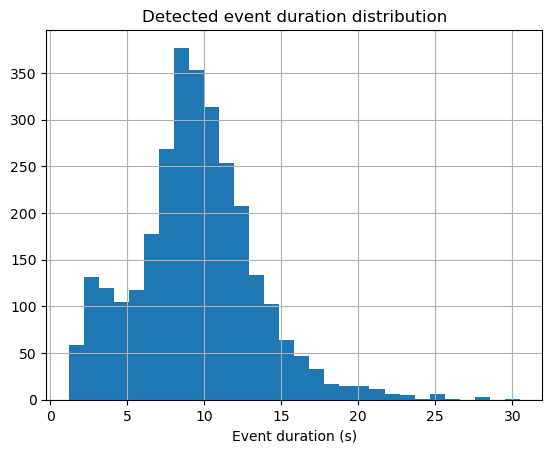

In [130]:
# inspect event durations

print(event_results["duration_seconds"].describe())
event_results["duration_seconds"].hist(bins=30)
plt.xlabel("Event duration (s)")
plt.title("Detected event duration distribution")
plt.show()

In [131]:
# # inspect the filtered-only events: how close did the denoised trace
# # come to triggering during that same time window?

# print("FILTERED-ONLY EVENTS")

# for (start, end), overlaps in zip(filtered_intervals, filtered_overlap_flags):
#     if overlaps:
#         continue

#     on_idx = int((start - denoised_full_trace.stats.starttime) * denoised_full_trace.stats.sampling_rate)
#     off_idx = int((end - denoised_full_trace.stats.starttime) * denoised_full_trace.stats.sampling_rate)
#     on_idx = max(on_idx, 0)
#     off_idx = min(off_idx, len(cft_filtered_denoised))

#     window_cft = cft_filtered_denoised[on_idx:off_idx]
#     peak_cft = np.nanmax(window_cft) if len(window_cft) else np.nan

#     print(
#         f"{start} - {end}  "
#         f"(duration {end - start:.2f}s)  "
#         f"peak denoised STA/LTA in window: {peak_cft:.2f}  "
#         f"(trigger threshold: {TRIGGER_ON})"
#     )

## SNR comparison and d

Needs `shishaldin_catalog_explorer.py`, `shishaldin_snr_comparison.py`, and
`shishaldin_snr_diagnostics.py` on the path (same folder as this notebook,
or added to `sys.path`).

In [132]:
# catalog + waveforms, built from Part 1 -- no file loading needed

catalog = event_results.copy()
catalog['start_time'] = pd.to_datetime(catalog['start_time'])
catalog['end_time'] = pd.to_datetime(catalog['end_time'])

waveforms = {
    'raw': raw_trace,
    'filtered': filtered_full_trace,
    'denoised': denoised_full_trace,
}

sheet = f"{START_TIME.date} ({STATION})"  # just a label for plot titles/filenames below

Skipping 634 event(s) missing a 'filtered' or 'denoised' detection.
Mean SNR improvement: 11.21 ± 7.62 dB over 1156 matched events


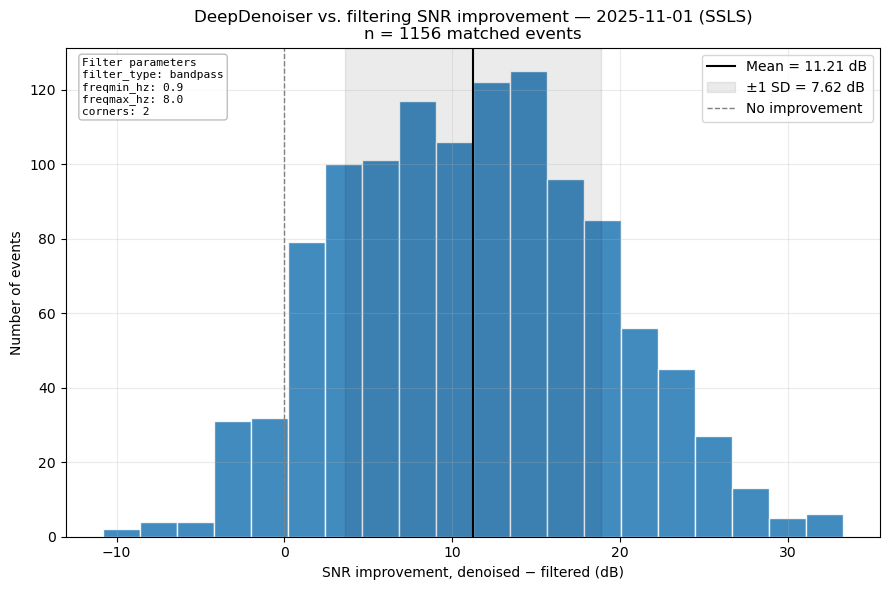

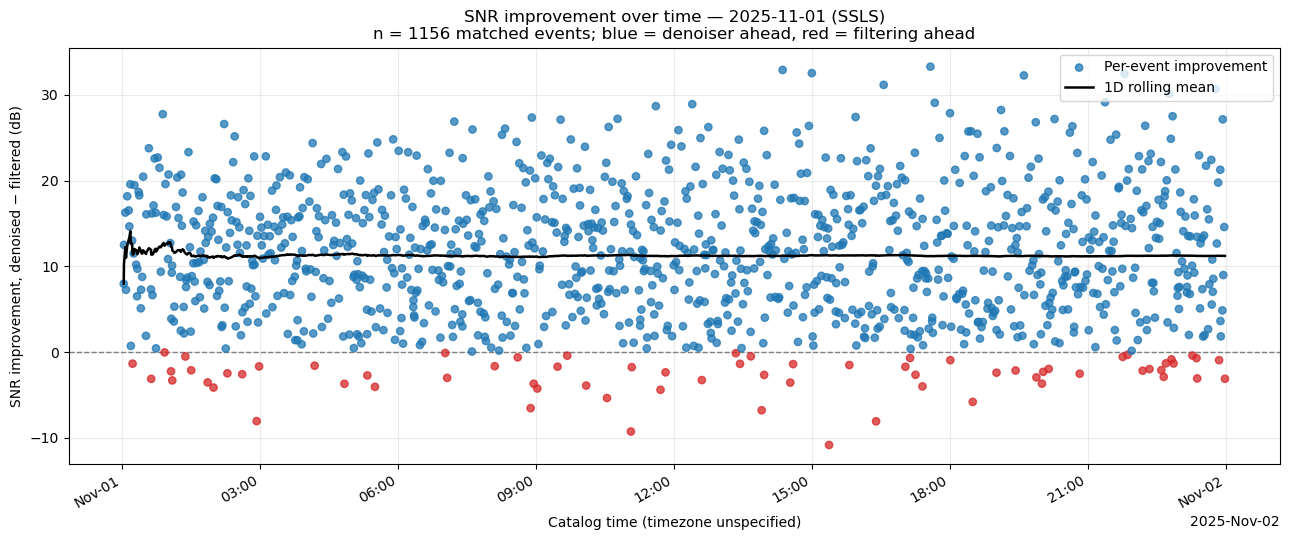

In [133]:
from shishaldin_snr_comparison import matched_snr_differences, plot_snr_difference_histogram, plot_snr_difference_timeseries

differences = matched_snr_differences(catalog)

# Pass the filter params actually used above, rather than relying on
# shishaldin_snr_comparison's own separately-hardcoded FILTER_PARAMS default
# (which could silently drift out of sync with FREQMIN/FREQMAX/CORNERS here).
filter_params = {
    'filter_type': 'bandpass',
    'freqmin_hz': FREQMIN,
    'freqmax_hz': FREQMAX,
    'corners': CORNERS,
}

fig_hist, mean_diff, std_diff = plot_snr_difference_histogram(differences, sheet, filter_params=filter_params)
fig_ts = plot_snr_difference_timeseries(differences, sheet)

print(f'Mean SNR improvement: {mean_diff:.2f} \u00b1 {std_diff:.2f} dB '
      f'over {len(differences)} matched events')

In [134]:
positive = (differences['snr_difference_db'] > 0).sum()
negative = (differences['snr_difference_db'] < 0).sum()
zero = (differences['snr_difference_db'] == 0).sum()

ratio = positive / negative if negative > 0 else float('inf')

print(f'Positive (denoiser ahead): {positive}')
print(f'Negative (filtering ahead): {negative}')
print(f'Zero (tied): {zero}')
print(f'Positive:negative ratio = {ratio:.2f} : 1' if negative > 0
      else 'Positive:negative ratio = undefined (no negative differences)')

total = len(differences)
print(f'{positive / total:.1%} favored the denoiser, {negative / total:.1%} favored filtering')

Positive (denoiser ahead): 1086
Negative (filtering ahead): 70
Zero (tied): 0
Positive:negative ratio = 15.51 : 1
93.9% favored the denoiser, 6.1% favored filtering


In [135]:
# # choose n random negative-SNR events and plot their waveforms

# from shishaldin_snr_diagnostics import select_random_negative_events, visualize_negative_events

# sample = select_random_negative_events(differences, n=10, seed=42)
# # Set export_dir to a real path (e.g. 'figs/negative_events') if you want
# # these saved as PNGs; the placeholder path here would fail to mkdir.
# figures = visualize_negative_events(sample, catalog, waveforms, export_dir=None)

# plt.show()

In [136]:
# # low-SNR vs. high-SNR: visual comparison + SDR/cross-correlation

# from shishaldin_snr_diagnostics import (
#     select_extreme_events, visualize_snr_groups,
#     summarize_group_metrics, plot_metric_comparison,
# )

# low = select_extreme_events(differences, n=10, kind='low')
# high = select_extreme_events(differences, n=10, kind='high')

# snr_figures = visualize_snr_groups(low, high, catalog, waveforms)

# metrics_low = summarize_group_metrics(low, catalog, waveforms, 'low')
# metrics_high = summarize_group_metrics(high, catalog, waveforms, 'high')

# print('\nLow-SNR group:')
# print(metrics_low[['event_number', 'max_correlation', 'sdr_db', 'best_lag_seconds']])
# print('\nHigh-SNR group:')
# print(metrics_high[['event_number', 'max_correlation', 'sdr_db', 'best_lag_seconds']])

# fig_cmp = plot_metric_comparison(metrics_low, metrics_high)
# plt.show()

### SDR for every matched event

The low-vs-high comparison above only scores the 10 lowest- and 10
highest-SNR events. Here we run the same `signal_distortion_ratio()` /
`compute_event_metrics()` from `shishaldin_snr_diagnostics.py` on *every*
matched event in `differences`, so we can see the full SDR distribution
and whether SDR tracks the SNR improvement across the whole catalog, not
just the extremes.

       event_number       sdr_db  max_correlation  best_lag_seconds
count   1156.000000  1156.000000      1156.000000       1156.000000
mean     791.012111     1.761238         0.910838         -0.000052
std      463.393313     1.367989         0.054231          0.002426
min        1.000000     0.019524         0.416250         -0.080000
25%      391.750000     0.701372         0.887753          0.000000
50%      784.000000     1.433488         0.920706          0.000000
75%     1186.750000     2.419842         0.946489          0.000000
max     1599.000000     9.589072         0.993947          0.020000


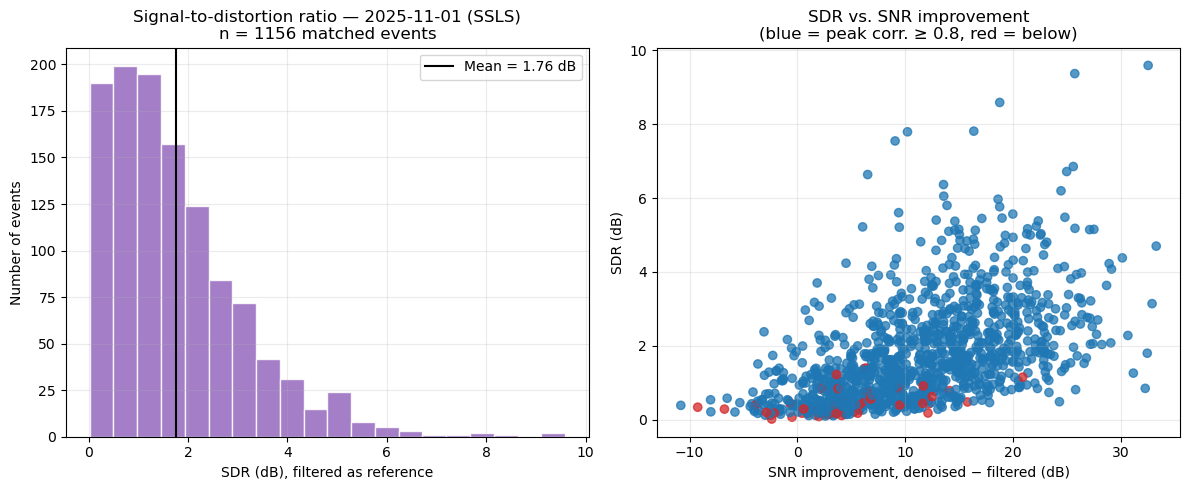

In [137]:
# SDR (and peak correlation) for every matched event, using
# compute_event_metrics() -> align_and_score() -> signal_distortion_ratio()
# from shishaldin_snr_diagnostics.py (filtered = reference, denoised = estimate)

from shishaldin_snr_diagnostics import compute_event_metrics

sdr_rows = []
for event_number in differences['event_number']:
    try:
        sdr_rows.append(compute_event_metrics(event_number, catalog, waveforms))
    except ValueError as exc:
        print(f'Event {event_number}: skipped ({exc})')

sdr_results = differences.merge(pd.DataFrame(sdr_rows), on='event_number', how='inner')

finite_sdr = sdr_results[np.isfinite(sdr_results['sdr_db'])]
n_dropped = len(sdr_results) - len(finite_sdr)
if n_dropped:
    print(f'Note: excluded {n_dropped} event(s) with infinite SDR '
          f'(filtered and denoised were identical) from the plots below.')

print(finite_sdr[['event_number', 'sdr_db', 'max_correlation', 'best_lag_seconds']]
      .describe())

# Plot 1: SDR distribution across all matched events
# Plot 2: SDR vs. SNR improvement, to see whether waveform-shape distortion
#         tracks the denoiser's SNR gain
fig, (ax_hist, ax_scatter) = plt.subplots(1, 2, figsize=(12, 5))

mean_sdr = finite_sdr['sdr_db'].mean()
ax_hist.hist(finite_sdr['sdr_db'], bins=20, color='tab:purple', edgecolor='white', alpha=.85)
ax_hist.axvline(mean_sdr, color='black', linewidth=1.5, label=f'Mean = {mean_sdr:.2f} dB')
ax_hist.set_xlabel('SDR (dB), filtered as reference')
ax_hist.set_ylabel('Number of events')
ax_hist.set_title(f'Signal-to-distortion ratio \u2014 {sheet}\nn = {len(finite_sdr)} matched events')
ax_hist.legend()
ax_hist.grid(alpha=.25)

colors = np.where(finite_sdr['max_correlation'] >= 0.8, 'tab:blue', 'tab:red')
ax_scatter.scatter(finite_sdr['snr_difference_db'], finite_sdr['sdr_db'],
                    c=colors, alpha=.75)
ax_scatter.set_xlabel('SNR improvement, denoised \u2212 filtered (dB)')
ax_scatter.set_ylabel('SDR (dB)')
ax_scatter.set_title('SDR vs. SNR improvement\n(blue = peak corr. \u2265 0.8, red = below)')
ax_scatter.grid(alpha=.25)

fig.tight_layout()
plt.show()

## Histogram with peak correlation coefficient across matched events

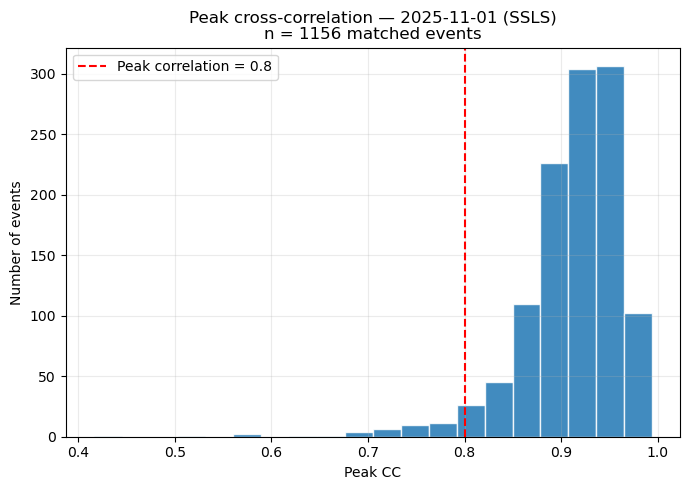

In [138]:
# Histogram of peak cross-correlation across all matched events
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    finite_sdr['max_correlation'],
    bins=20,
    edgecolor='white',
    alpha=0.85
)

# Show the 0.8 threshold used elsewhere in the analysis
ax.axvline(
    0.8,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Peak correlation = 0.8'
)

ax.set_xlabel('Peak CC')
ax.set_ylabel('Number of events')
ax.set_title(
    f'Peak cross-correlation — {sheet}\n'
    f'n = {len(finite_sdr)} matched events'
)

ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

### Create csv file with snr event number, change in SNR, SDR, and peak_CC

In [139]:
import pandas as pd
from shishaldin_snr_diagnostics import compute_event_metrics

cc_sdr_snr_rows = []

for _, row in differences.iterrows():
    event_number = row['event_number']

    try:
        metrics = compute_event_metrics(
            event_number,
            catalog,
            waveforms,
            reference_label='filtered',
            estimate_label='denoised',
            padding_seconds=0,
            max_lag_seconds=0.5
        )

        cc_sdr_snr_rows.append({
            'event_number': event_number,
            'SNR_difference_dB': row['snr_difference_db'],
            'peak_CC': metrics['max_correlation'],
            'SDR_dB': metrics['sdr_db']
        })

    except Exception as e:
        print(f"Event {event_number} failed: {e}")

signal_metrics = pd.DataFrame(cc_sdr_snr_rows)

signal_metrics.to_csv("signal_metrics_24_hours.csv", index=False)


## Plot raw waveform, filtered, and denoised and highlight event for one negative and positive delta SNR

In [140]:
def plot_sample_events(
    sample,
    waveforms,
    catalog_file="shishaldin_catalog_1_day.csv",
    event_padding_seconds=30,
    show=True,
    export_dir=None,
):
    """
    Plot each event in `sample` next to the event immediately before it
    (chronologically) in the catalog CSV.

    Left column  : sample event (e.g. a negative-SNR-difference event), red.
    Right column : the catalog event that occurred just before it, blue.
    Rows         : Raw / Filtered / Denoised.

    sample    : DataFrame with an `event_number` column, or any iterable of event numbers.
    waveforms : dict with 'raw', 'filtered', 'denoised' ObsPy Traces (from Part 1).
    """
    from pathlib import Path

    # ---------------------------------------------------------
    # Load catalog and collapse to one record per event
    # ---------------------------------------------------------
    catalog = pd.read_csv(catalog_file, parse_dates=["start_time", "end_time"])

    events = {}
    for event_number, grp in catalog.groupby("event_number"):
        rec = {"start": grp["start_time"].min(), "end": grp["end_time"].max()}
        for det in ("filtered", "denoised"):
            row = grp[grp["detection_type"] == det]
            rec[det] = row.iloc[0] if len(row) else None
        events[int(event_number)] = rec

    # event numbers are NOT chronological (denoised-only events are numbered
    # last), so "previous" is defined by start time, not by event_number - 1
    chronological = sorted(events, key=lambda n: events[n]["start"])
    position = {n: i for i, n in enumerate(chronological)}

    if isinstance(sample, pd.DataFrame):
        sample_numbers = sample["event_number"].astype(int).tolist()
    else:
        sample_numbers = [int(n) for n in sample]

    if export_dir is not None:
        export_dir = Path(export_dir)
        export_dir.mkdir(parents=True, exist_ok=True)

    # ---------------------------------------------------------
    # Helpers
    # ---------------------------------------------------------
    rows = [("raw", "Raw"), ("filtered", "Filtered"), ("denoised", "Denoised")]
    waveform_ylim = (-10e-6, 10e-6)
    waveform_yticks = [-5e-6, 0, 5e-6]

    def to_utc(ts):
        return UTCDateTime(ts.to_pydatetime())

    def event_window(rec, det):
        """(start, end) of a detection, falling back to the other one."""
        row = rec[det] if rec[det] is not None else (
            rec["filtered"] if rec["filtered"] is not None else rec["denoised"]
        )
        return to_utc(row["start_time"]), to_utc(row["end_time"])

    def snr_label(rec, det):
        row = rec[det]
        if row is None:
            return "not detected"
        text = f"SNR = {row['snr_db']:.2f} dB"
        if det == "denoised" and rec["filtered"] is not None:
            text += f" | \u0394SNR = {row['snr_db'] - rec['filtered']['snr_db']:.2f} dB"
        return text

    raw_peaks = []

    def draw_column(axes_col, rec, number, color, heading):
        ev_start, ev_end = to_utc(rec["start"]), to_utc(rec["end"])
        view_start = ev_start - event_padding_seconds
        view_end = ev_end + event_padding_seconds

        for ax, (key, name) in zip(axes_col, rows):
            trace = waveforms[key].slice(starttime=view_start, endtime=view_end)

            if trace.stats.npts == 0:
                ax.text(0.5, 0.5, "no data in loaded window",
                        transform=ax.transAxes, ha="center", va="center")
            else:
                data = trace.data.astype(float)
                if key == "raw":
                    # raw has offset/drift (it is never demeaned or detrended),
                    # which pushes it outside the fixed +/-10 um/s axis.
                    # Remove a linear trend for display only.
                    x = np.arange(len(data))
                    data = data - np.polyval(np.polyfit(x, data, 1), x)
                    raw_peaks.append(np.max(np.abs(data)))
                ax.plot(trace.times("matplotlib"), data,
                        linewidth=0.6, color="black")

            # raw + filtered share the filtered detection window;
            # denoised uses its own detection window
            w_start, w_end = event_window(rec, "denoised" if key == "denoised" else "filtered")
            ax.axvspan(w_start.matplotlib_date, w_end.matplotlib_date,
                       color=color, alpha=0.2)

            if key == "raw":
                ax.set_title(f"{heading} - Raw", fontsize=15)
                ax.plot([], [], color="none", label="Raw waveform")
            else:
                ax.set_title(name, fontsize=15)
                ax.plot([], [], color="none", label=snr_label(rec, key))

            ax.legend(loc="upper right", handlelength=0)
            if key == "raw":
                ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
            else:
                ax.set_ylim(waveform_ylim)
                ax.set_yticks(waveform_yticks)
                ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
            ax.grid(True, alpha=0.3)
            ax.margins(x=0)
            ax.set_xlim(view_start.matplotlib_date, view_end.matplotlib_date)
            ax.xaxis.set_major_locator(mdates.AutoDateLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

        axes_col[-1].set_xlabel("UTC Time")

    # ---------------------------------------------------------
    # One figure per sample event
    # ---------------------------------------------------------
    figures = []

    for number in sample_numbers:
        print("\n" + "=" * 70)
        print(f"Sample event: {number}")

        if number not in events:
            print("  Not in catalog. Skipping.")
            continue
        if position[number] == 0:
            print("  First event in the catalog, no previous event. Skipping.")
            continue

        prev_number = chronological[position[number] - 1]
        sample_rec, prev_rec = events[number], events[prev_number]

        print(f"  Sample:   #{number}  {sample_rec['start']} -> {sample_rec['end']}")
        print(f"  Previous: #{prev_number}  {prev_rec['start']} -> {prev_rec['end']}")

        fig, axes = plt.subplots(3, 2, figsize=(18, 9), sharey="row")
        raw_peaks.clear()

        draw_column(axes[:, 0], sample_rec, number, "red", f"Event {number}")
        draw_column(
            axes[:, 1], prev_rec, prev_number, "blue",
            f"Previous event (#{prev_number})\n"
            f"{prev_rec['start'].strftime('%Y-%m-%d %H:%M:%S')}",
        )

        # raw row: shared autoscale across both columns (sharey="row")
        if raw_peaks:
            peak = max(raw_peaks) * 1.1
            axes[0, 0].set_ylim(-peak, peak)

        for ax in axes[:, 0]:
            ax.set_ylabel("Velocity (m/s)")

        fig.tight_layout()

        if export_dir is not None:
            fig.savefig(export_dir / f"event_{number}_vs_previous.png",
                        dpi=150, bbox_inches="tight")

        figures.append(fig)
        if show:
            plt.show()

    return figures

Only 70 negative event(s) available; using all of them.

Sample event: 1336
  Sample:   #1336  2025-11-01 20:09:07.340000 -> 2025-11-01 20:09:25.440000
  Previous: #1335  2025-11-01 20:08:45.920000 -> 2025-11-01 20:08:59.740000


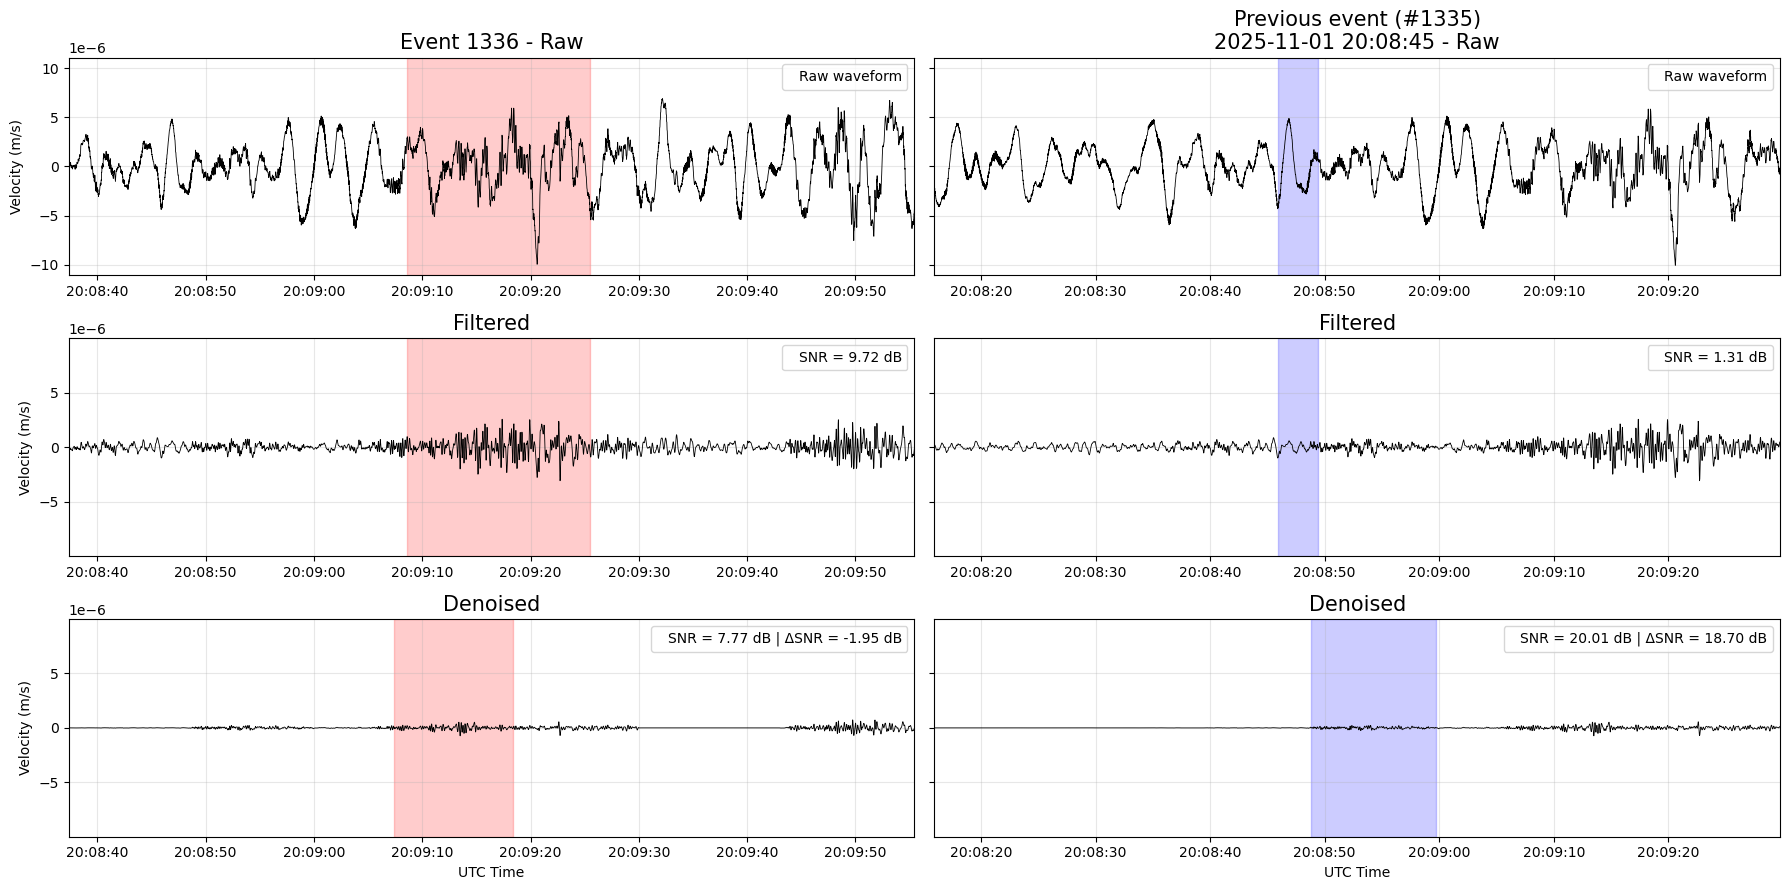

In [142]:
from shishaldin_snr_diagnostics import select_random_negative_events

sample = select_random_negative_events(differences, n=1, seed=10)

figures = plot_sample_events(
    sample,
    waveforms,
    catalog_file="shishaldin_catalog_1_week.csv",  # or "shishaldin_catalog_1_day-2.csv" (your uploaded file)
    event_padding_seconds=30,
    export_dir=None,   # e.g. "figs/negative_vs_previous" to save PNGs
)

## Week-long Data

In [143]:
import os
import gc

# ---- weekly run settings (separate from the single-day START_TIME/STOP_TIME above) ----
WEEK_START = UTCDateTime("2025-11-01T00:00:00")
N_DAYS = 7
WINDOW_HOURS = 24

# Extra data around each window so STA/LTA has warmed up at the start and
# events crossing the day boundary are complete. Only events that START
# inside [day_start, day_end) are kept, so nothing is double-counted.
LEAD_IN_SECONDS = STARTUP_SECONDS
TAIL_SECONDS = 60

OUTPUT_DIR = "shishaldin_week"
PLOT_PER_DAY = True
N_NEGATIVE_PER_DAY = 3      # random negative-SNR events plotted for each day

In [144]:
def process_window(day_start, day_end, first_event_number=1):
    """
    Download, filter, denoise and run STA/LTA on ONE window, then build its
    long-format catalog (same columns as event_results in Part 1).

    Returns (catalog_df, waveforms_dict).
    """
    win_start = day_start - LEAD_IN_SECONDS
    win_end = day_end + TAIL_SECONDS

    stream = client.get_waveforms(
        NETWORK, STATION, LOCATION, CHANNEL,
        win_start - EDGE_TRIM_SECONDS, win_end + EDGE_TRIM_SECONDS,
    )
    stream.remove_response(inventory=inv, output="VEL")

    bhz = stream.select(channel="BHZ")
    if len(bhz) > 1:
        print(f"  warning: {len(bhz)} BHZ segments (data gaps); using the longest")
    base = max(bhz, key=lambda tr: tr.stats.npts)

    # raw
    raw_trace = base.copy()
    raw_trace.trim(starttime=win_start, endtime=win_end)

    # filtered
    filtered = base.copy()
    filtered.detrend("demean")
    filtered.detrend("linear")
    filtered.filter("bandpass", freqmin=FREQMIN, freqmax=FREQMAX,
                    corners=CORNERS, zerophase=True)
    filtered.trim(starttime=win_start, endtime=win_end)

    # denoised (match the filtered sampling rate, as in Part 1)
    denoised = model.annotate(Stream([filtered]))[0].copy()
    if denoised.stats.sampling_rate != filtered.stats.sampling_rate:
        denoised.resample(filtered.stats.sampling_rate)

    # STA/LTA (run_sta_lta is defined in Part 1)
    _, trig_f = run_sta_lta(filtered)
    _, trig_d = run_sta_lta(denoised)

    def to_intervals(trace, triggers):
        fs = trace.stats.sampling_rate
        return [(trace.stats.starttime + on / fs, trace.stats.starttime + off / fs)
                for on, off in triggers]

    f_int = to_intervals(filtered, trig_f)
    d_int = to_intervals(denoised, trig_d)

    def window_metrics(trace, start, end):
        ev = trace.copy()
        ev.trim(starttime=start, endtime=end)
        sig = ev.data.astype(float)
        signal_rms = np.sqrt(np.mean(sig ** 2))
        max_amp = np.max(np.abs(sig))

        noise = trace.copy()
        noise.trim(starttime=start - LTA_SECONDS, endtime=start)
        if len(noise.data) > 0:
            noise_rms = np.sqrt(np.mean(noise.data.astype(float) ** 2))
            snr = 20 * np.log10(signal_rms / noise_rms) if noise_rms > 0 else np.nan
        else:
            noise_rms, snr = np.nan, np.nan
        return signal_rms, noise_rms, snr, max_amp

    # pair filtered/denoised detections (same logic as Part 1):
    # filtered detections first, then denoised-only ones
    events, matched = [], set()
    for fs_, fe_ in f_int:
        partner = None
        for j, (ds_, de_) in enumerate(d_int):
            if j not in matched and fs_ < de_ and ds_ < fe_:
                matched.add(j)
                partner = (ds_, de_)
                break
        events.append({"filtered": (fs_, fe_), "denoised": partner})
    for j, (ds_, de_) in enumerate(d_int):
        if j not in matched:
            events.append({"filtered": None, "denoised": (ds_, de_)})

    # keep only events that START inside this day's window
    def event_start(ev):
        return min(w[0] for w in (ev["filtered"], ev["denoised"]) if w is not None)

    events = [ev for ev in events if day_start <= event_start(ev) < day_end]

    rows = []
    for number, ev in enumerate(events, start=first_event_number):
        for det, trace in (("filtered", filtered), ("denoised", denoised)):
            if ev[det] is None:
                continue
            s, e = ev[det]
            sig_rms, noise_rms, snr, max_amp = window_metrics(trace, s, e)
            rows.append({
                "event_number": number,
                "detection_type": det,
                "start_time": s.strftime("%Y-%m-%dT%H:%M:%S.%f"),
                "end_time": e.strftime("%Y-%m-%dT%H:%M:%S.%f"),
                "duration_seconds": float(e - s),
                "signal_rms": float(sig_rms),
                "noise_rms": float(noise_rms),
                "snr_db": float(snr),
                "max_amplitude": float(max_amp),
            })

    columns = ["event_number", "detection_type", "start_time", "end_time",
               "duration_seconds", "signal_rms", "noise_rms", "snr_db", "max_amplitude"]
    catalog_df = (pd.DataFrame(rows, columns=columns)
                  .sort_values(["event_number", "detection_type"])
                  .reset_index(drop=True))

    waveforms_day = {"raw": raw_trace, "filtered": filtered, "denoised": denoised}
    return catalog_df, waveforms_day


######################################################################
Day 1/7: 2025-11-01T00:00:00.000000Z -> 2025-11-02T00:00:00.000000Z
  1795 events, 2952 detection rows
Skipping 638 event(s) missing a 'filtered' or 'denoised' detection.
Only 71 negative event(s) available; using all of them.

Sample event: 885
  Sample:   #885  2025-11-01 13:40:28.900000 -> 2025-11-01 13:40:38.660000
  Previous: #884  2025-11-01 13:40:14.300000 -> 2025-11-01 13:40:25.060000


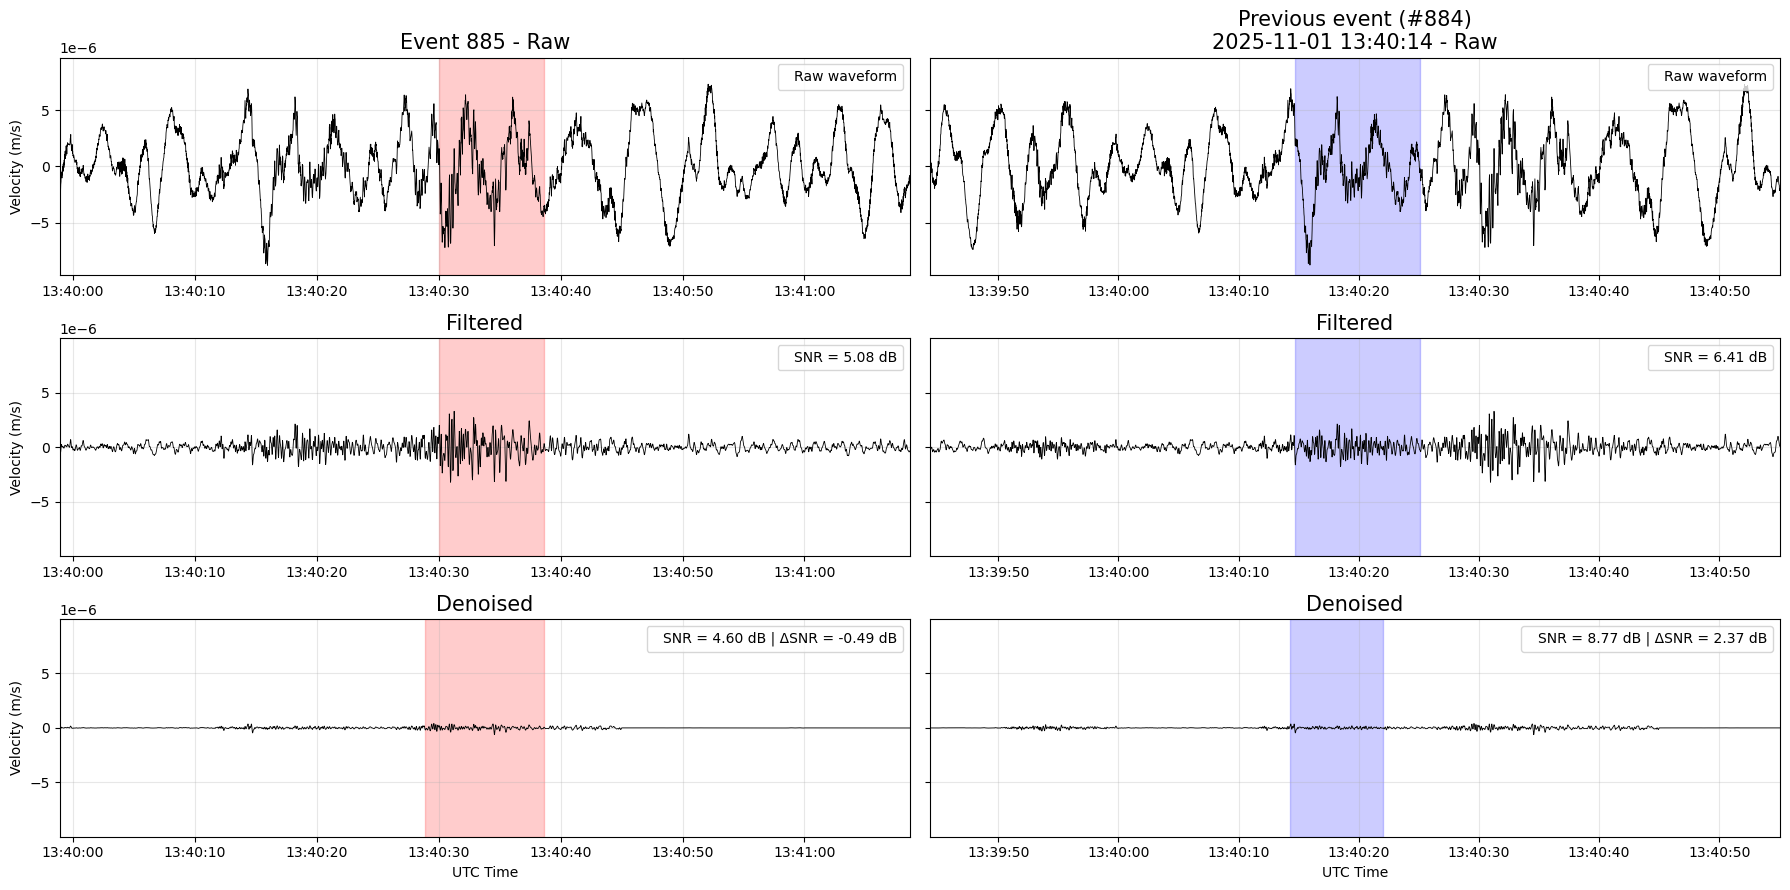


Sample event: 1117
  Sample:   #1117  2025-11-01 17:02:08.700000 -> 2025-11-01 17:02:17.400000
  Previous: #1116  2025-11-01 17:01:46.420000 -> 2025-11-01 17:02:00.380000


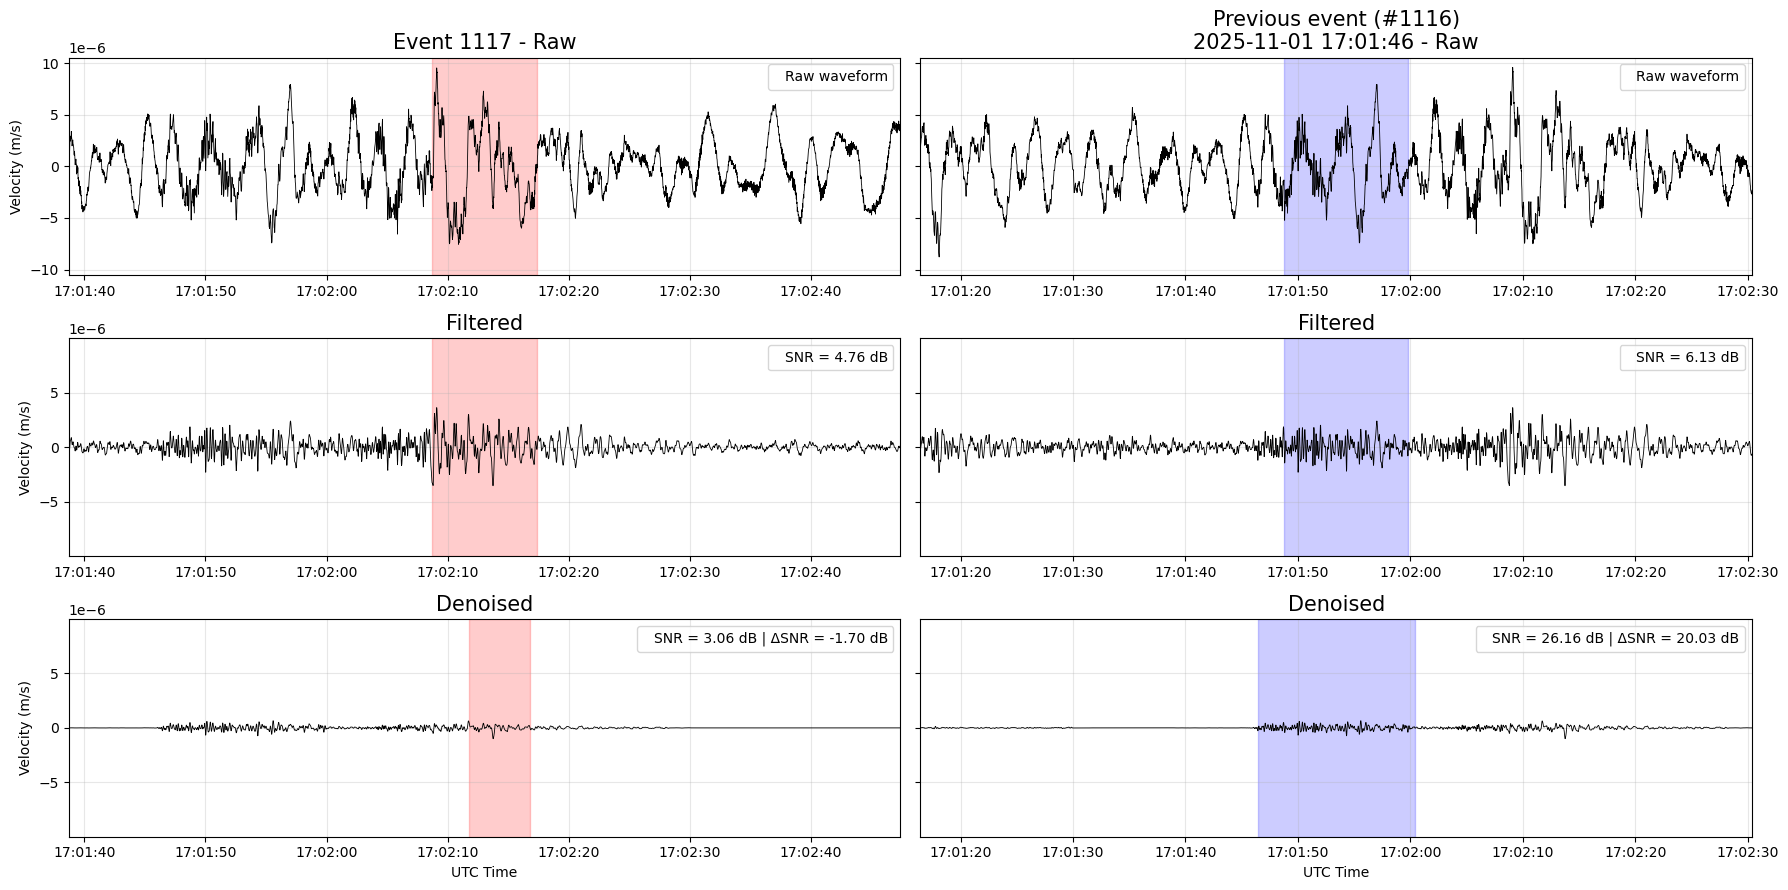


Sample event: 1461
  Sample:   #1461  2025-11-01 21:51:56.600000 -> 2025-11-01 21:52:04.920000
  Previous: #1460  2025-11-01 21:51:22.460000 -> 2025-11-01 21:51:33.380000


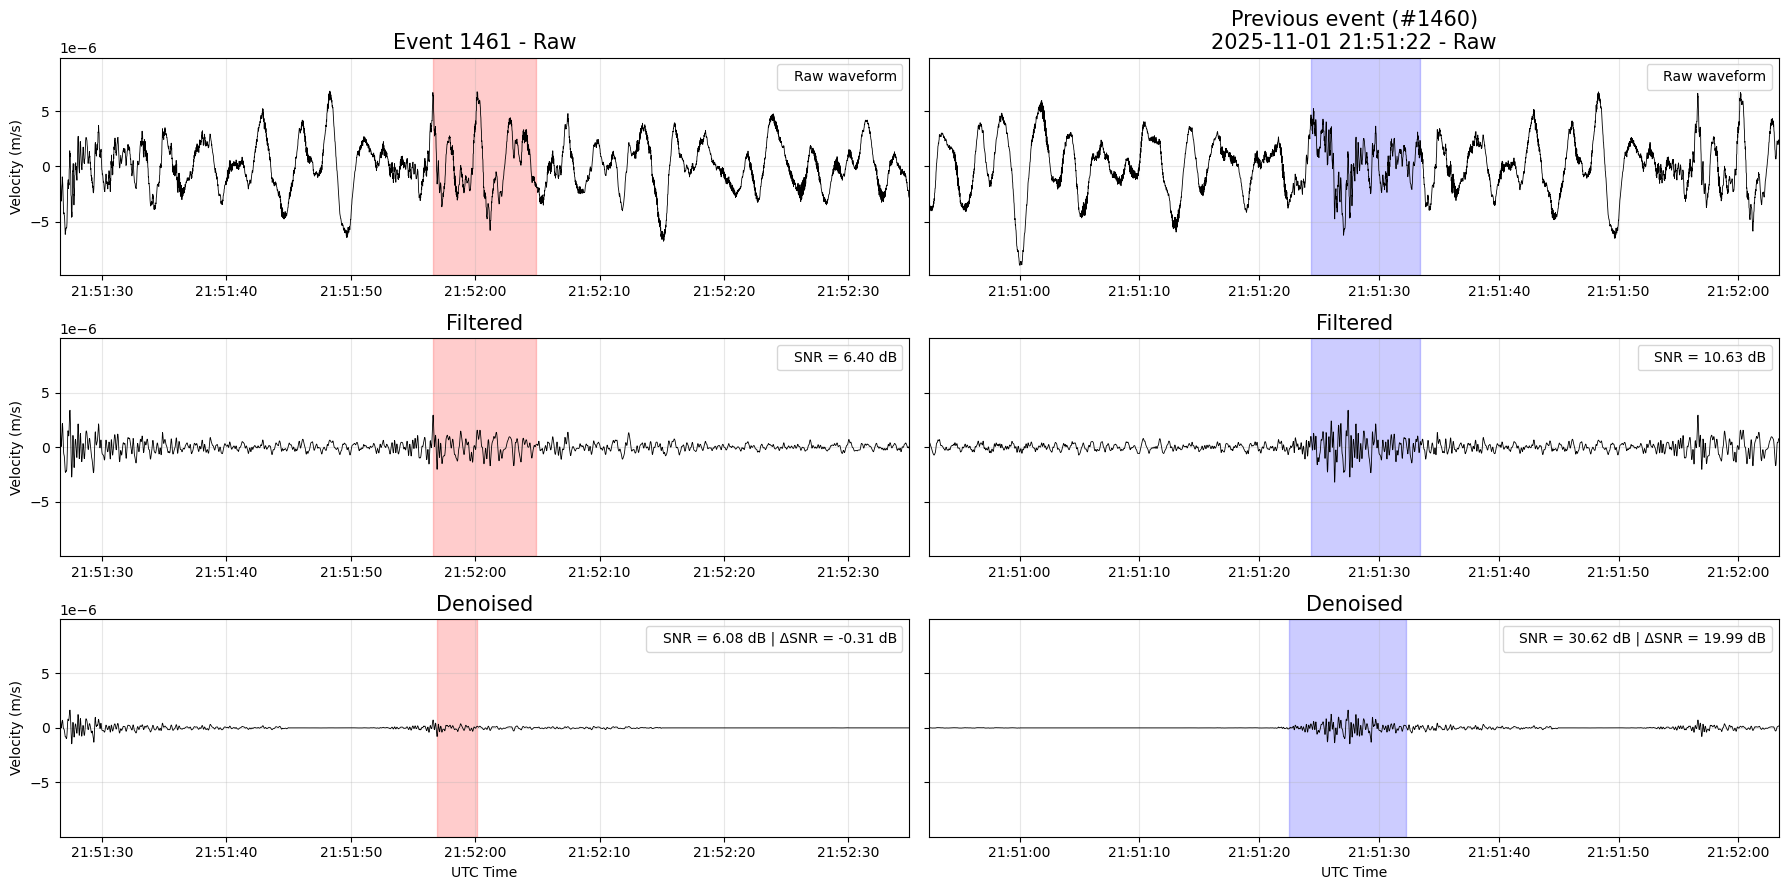


######################################################################
Day 2/7: 2025-11-02T00:00:00.000000Z -> 2025-11-03T00:00:00.000000Z
  1864 events, 3048 detection rows
Skipping 680 event(s) missing a 'filtered' or 'denoised' detection.
Only 114 negative event(s) available; using all of them.

Sample event: 2579
  Sample:   #2579  2025-11-02 11:28:48.220000 -> 2025-11-02 11:29:00.760000
  Previous: #3540  2025-11-02 11:28:43.280000 -> 2025-11-02 11:28:47.120000


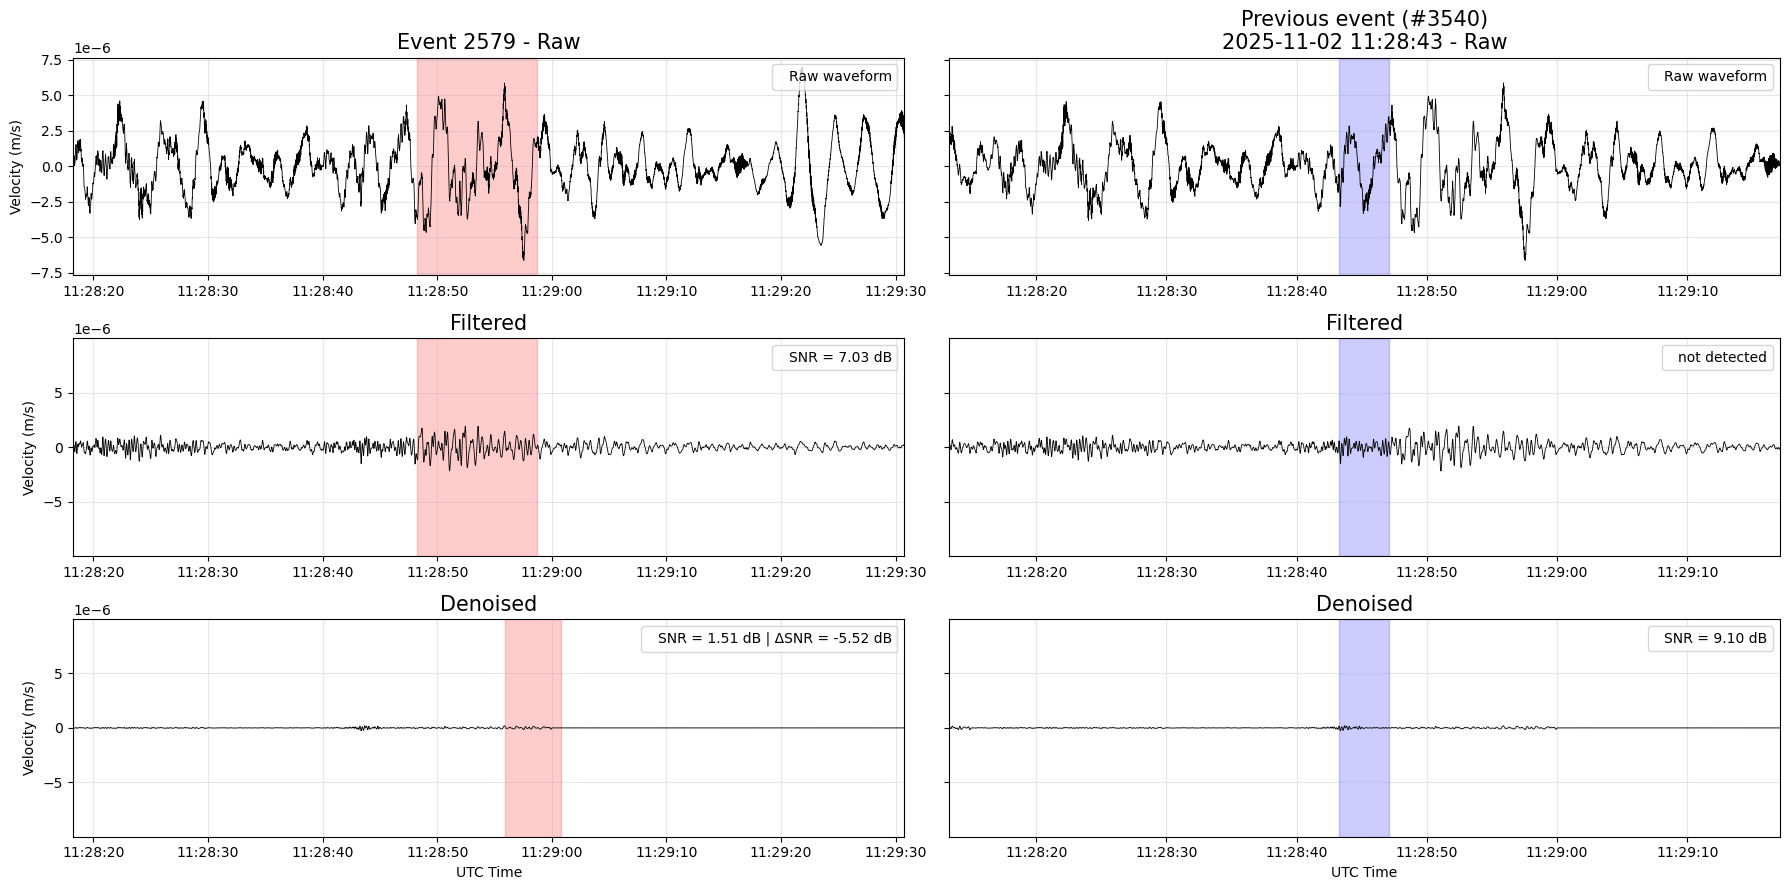


Sample event: 2638
  Sample:   #2638  2025-11-02 12:21:20.260000 -> 2025-11-02 12:21:40.120000
  Previous: #2637  2025-11-02 12:21:09.960000 -> 2025-11-02 12:21:14.060000


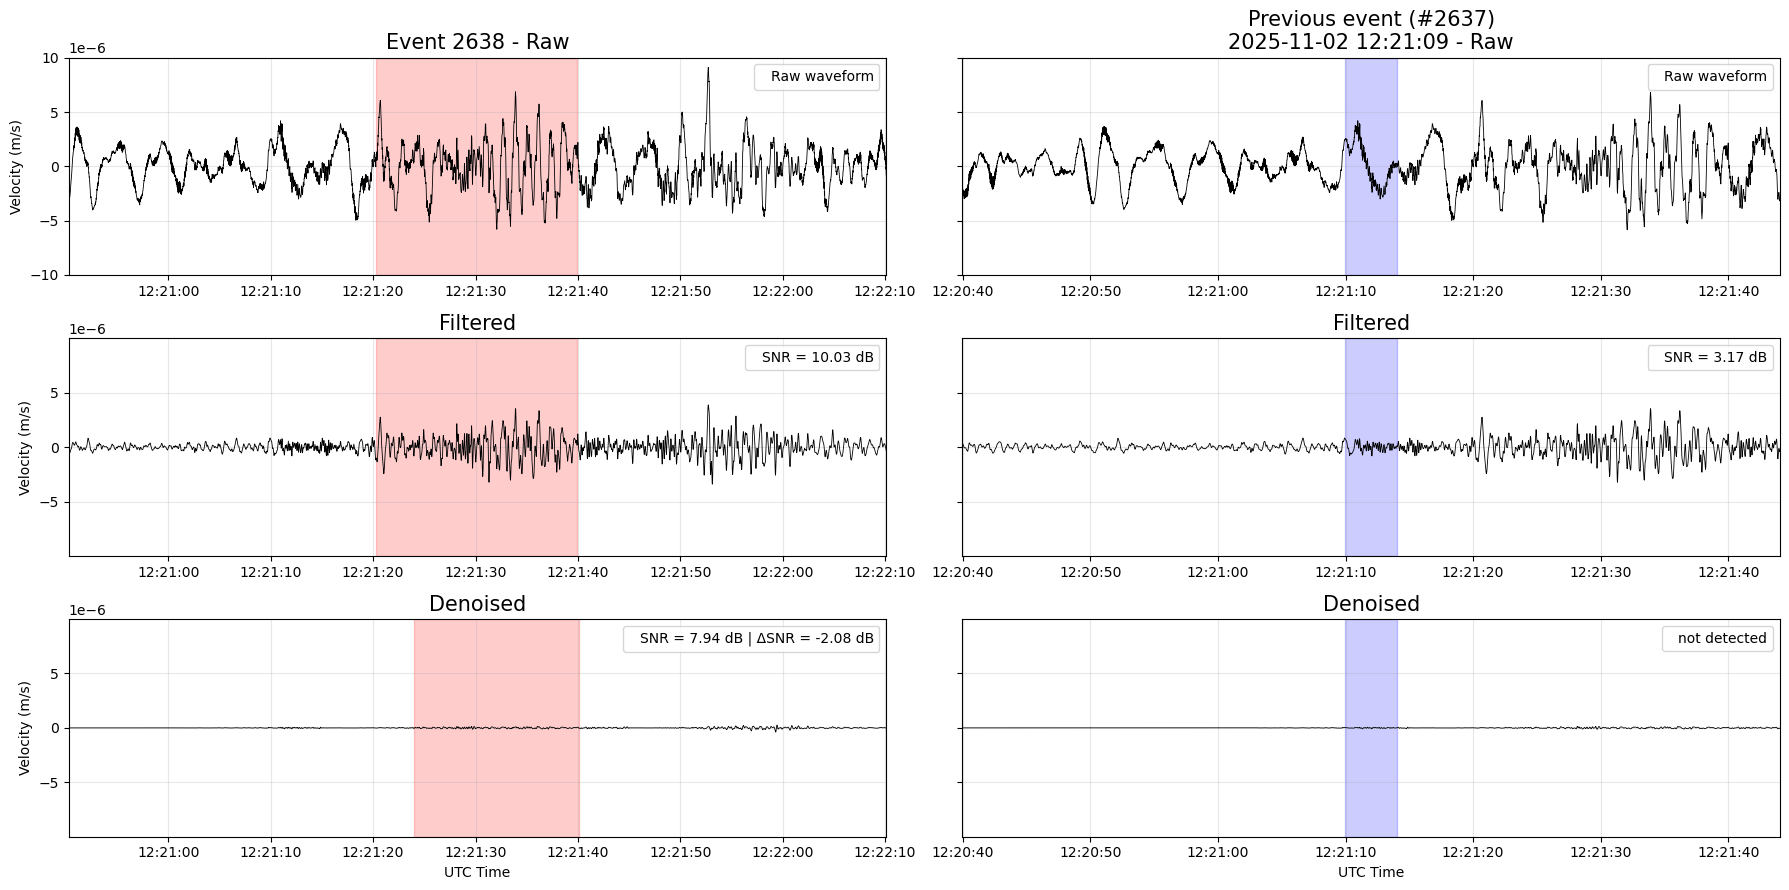


Sample event: 3143
  Sample:   #3143  2025-11-02 19:37:53.560000 -> 2025-11-02 19:38:10.840000
  Previous: #3627  2025-11-02 19:37:23.660000 -> 2025-11-02 19:37:31.520000


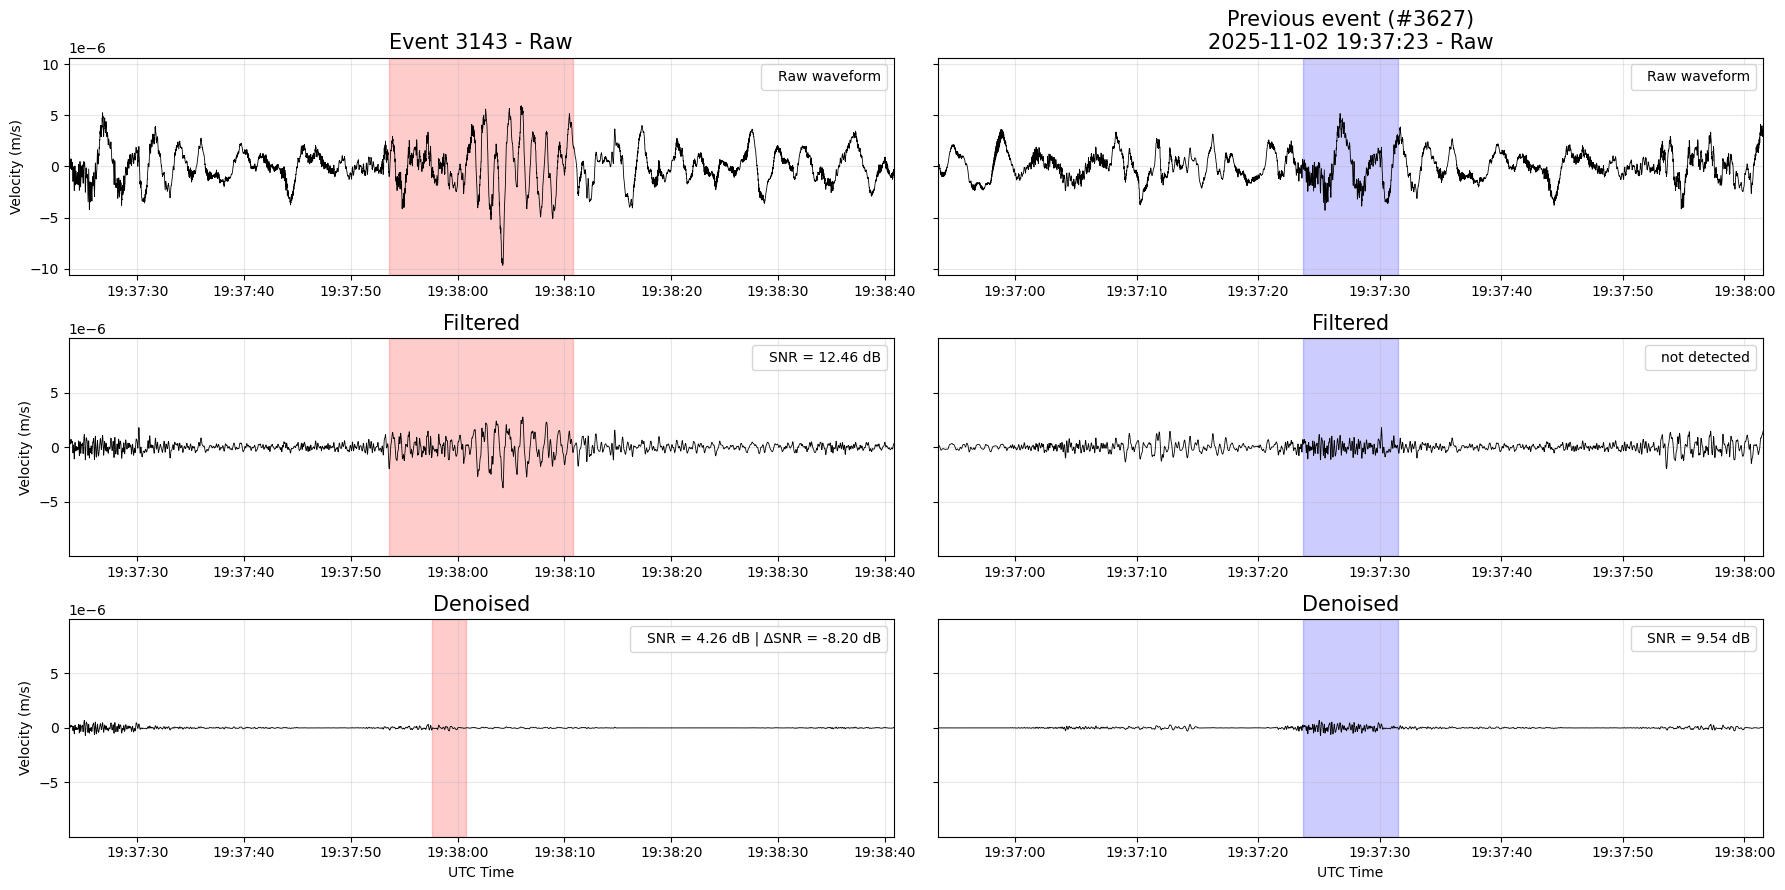


######################################################################
Day 3/7: 2025-11-03T00:00:00.000000Z -> 2025-11-04T00:00:00.000000Z
  1877 events, 3060 detection rows
Skipping 694 event(s) missing a 'filtered' or 'denoised' detection.
Only 124 negative event(s) available; using all of them.

Sample event: 3776
  Sample:   #3776  2025-11-03 01:44:32.600000 -> 2025-11-03 01:44:42.060000
  Previous: #3775  2025-11-03 01:43:47.740000 -> 2025-11-03 01:44:00.840000


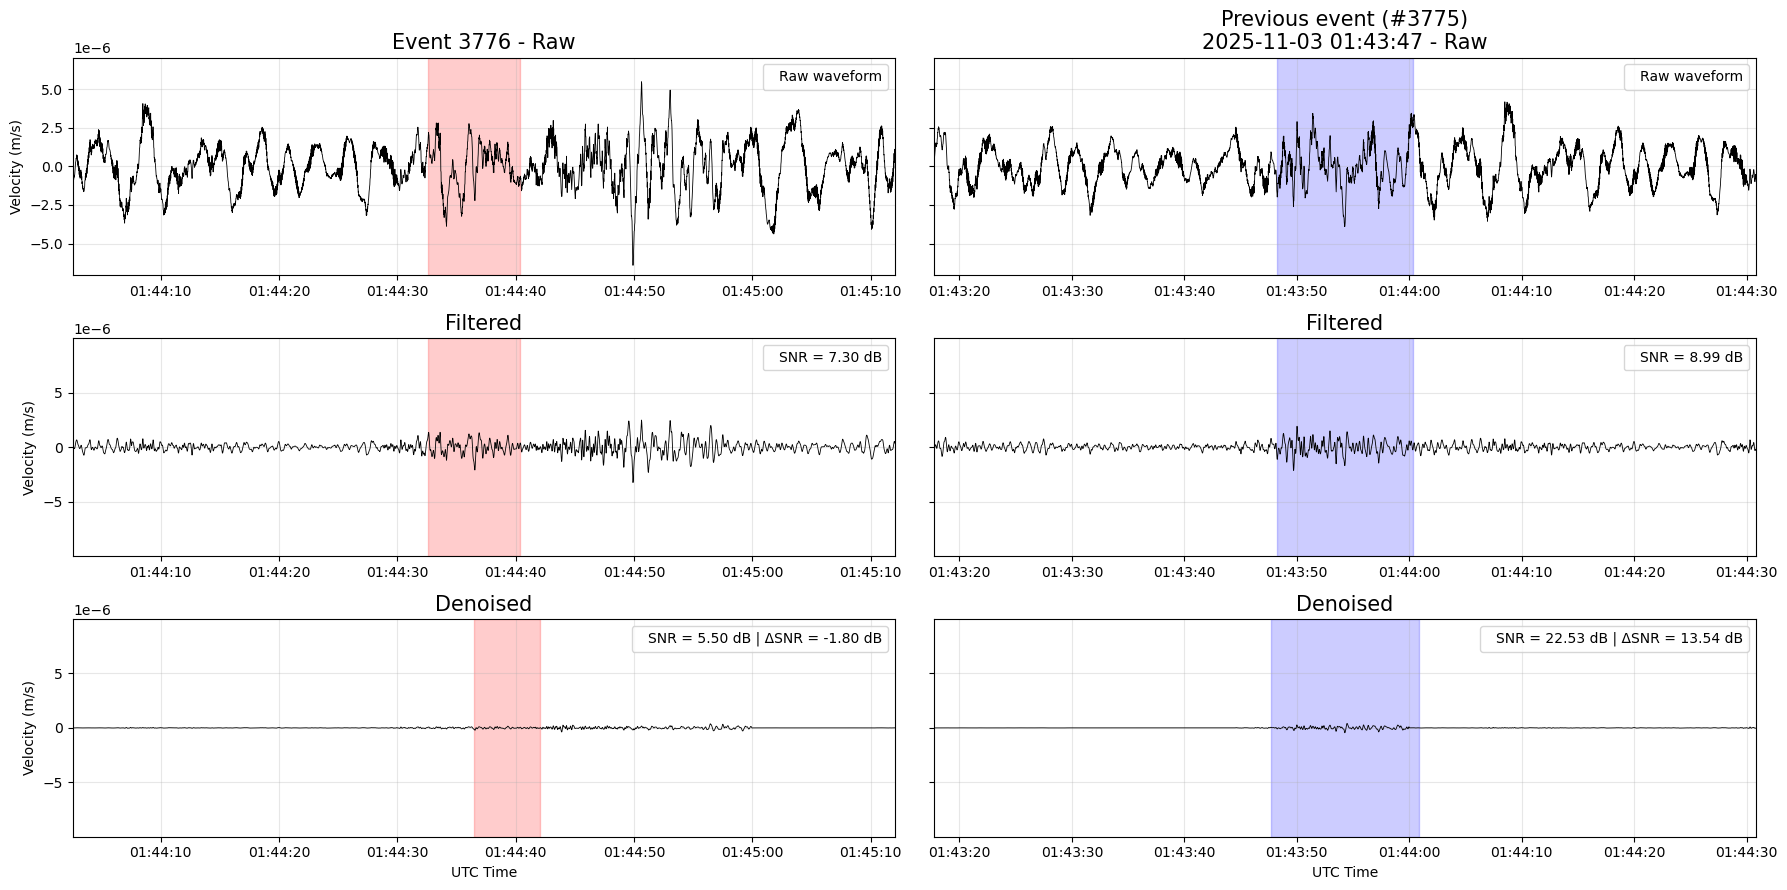


Sample event: 4067
  Sample:   #4067  2025-11-03 05:57:23.580000 -> 2025-11-03 05:57:32.780000
  Previous: #4066  2025-11-03 05:56:13.740000 -> 2025-11-03 05:56:26.100000


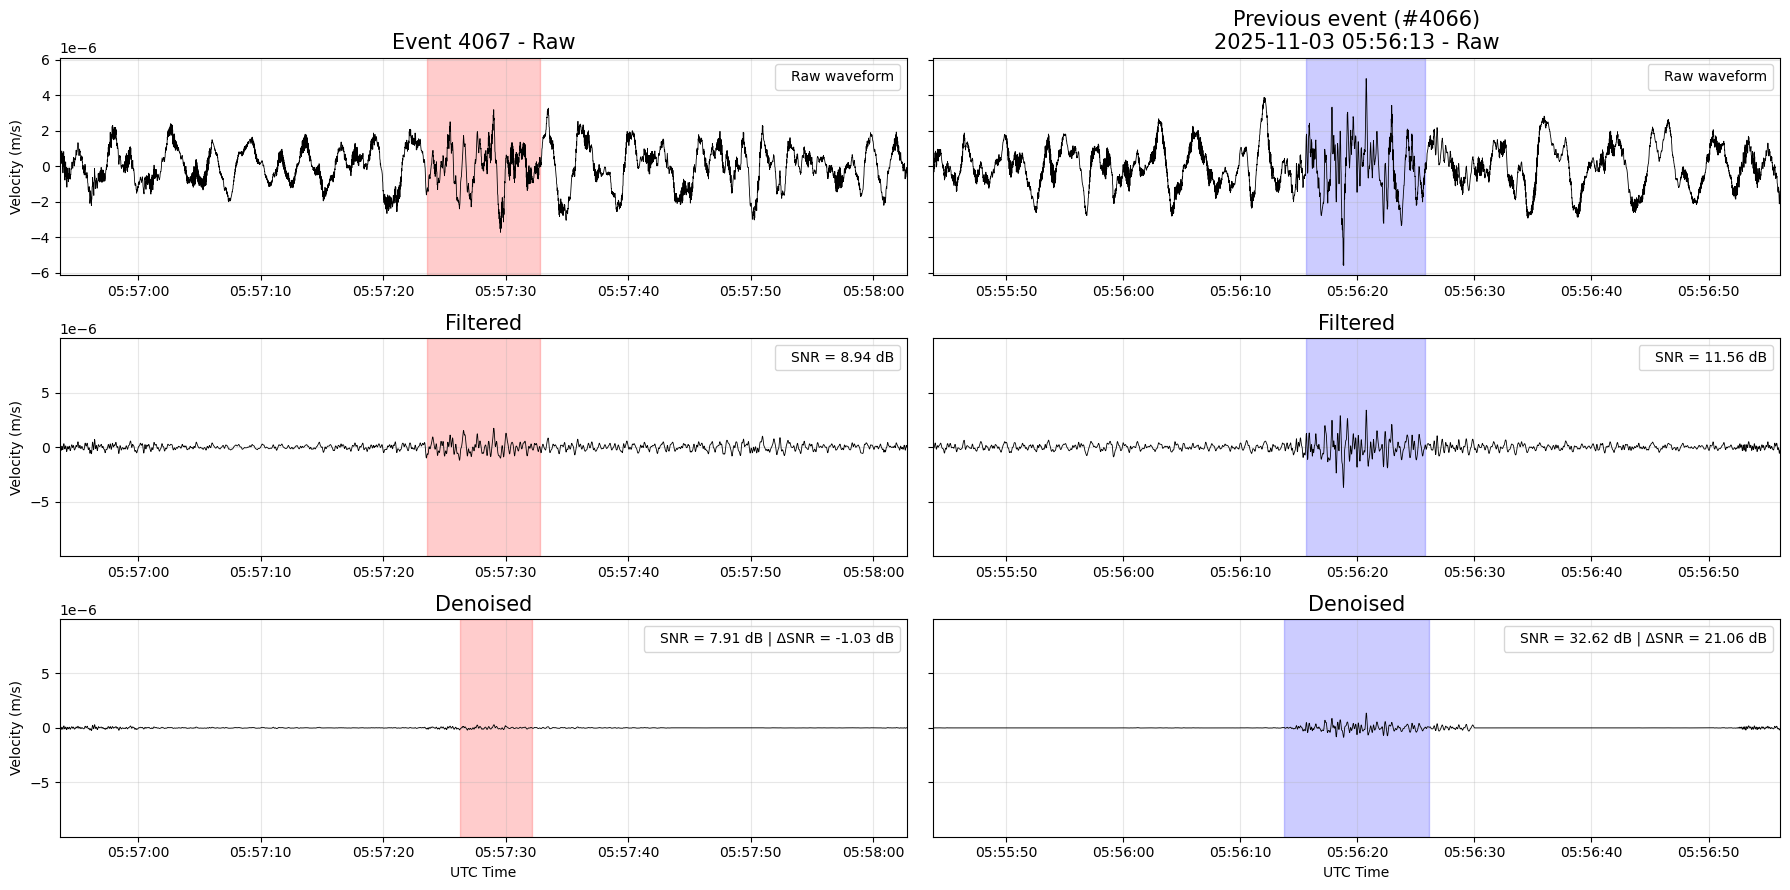


Sample event: 5096
  Sample:   #5096  2025-11-03 20:52:34.940000 -> 2025-11-03 20:52:42.160000
  Previous: #5095  2025-11-03 20:52:02.880000 -> 2025-11-03 20:52:15.440000


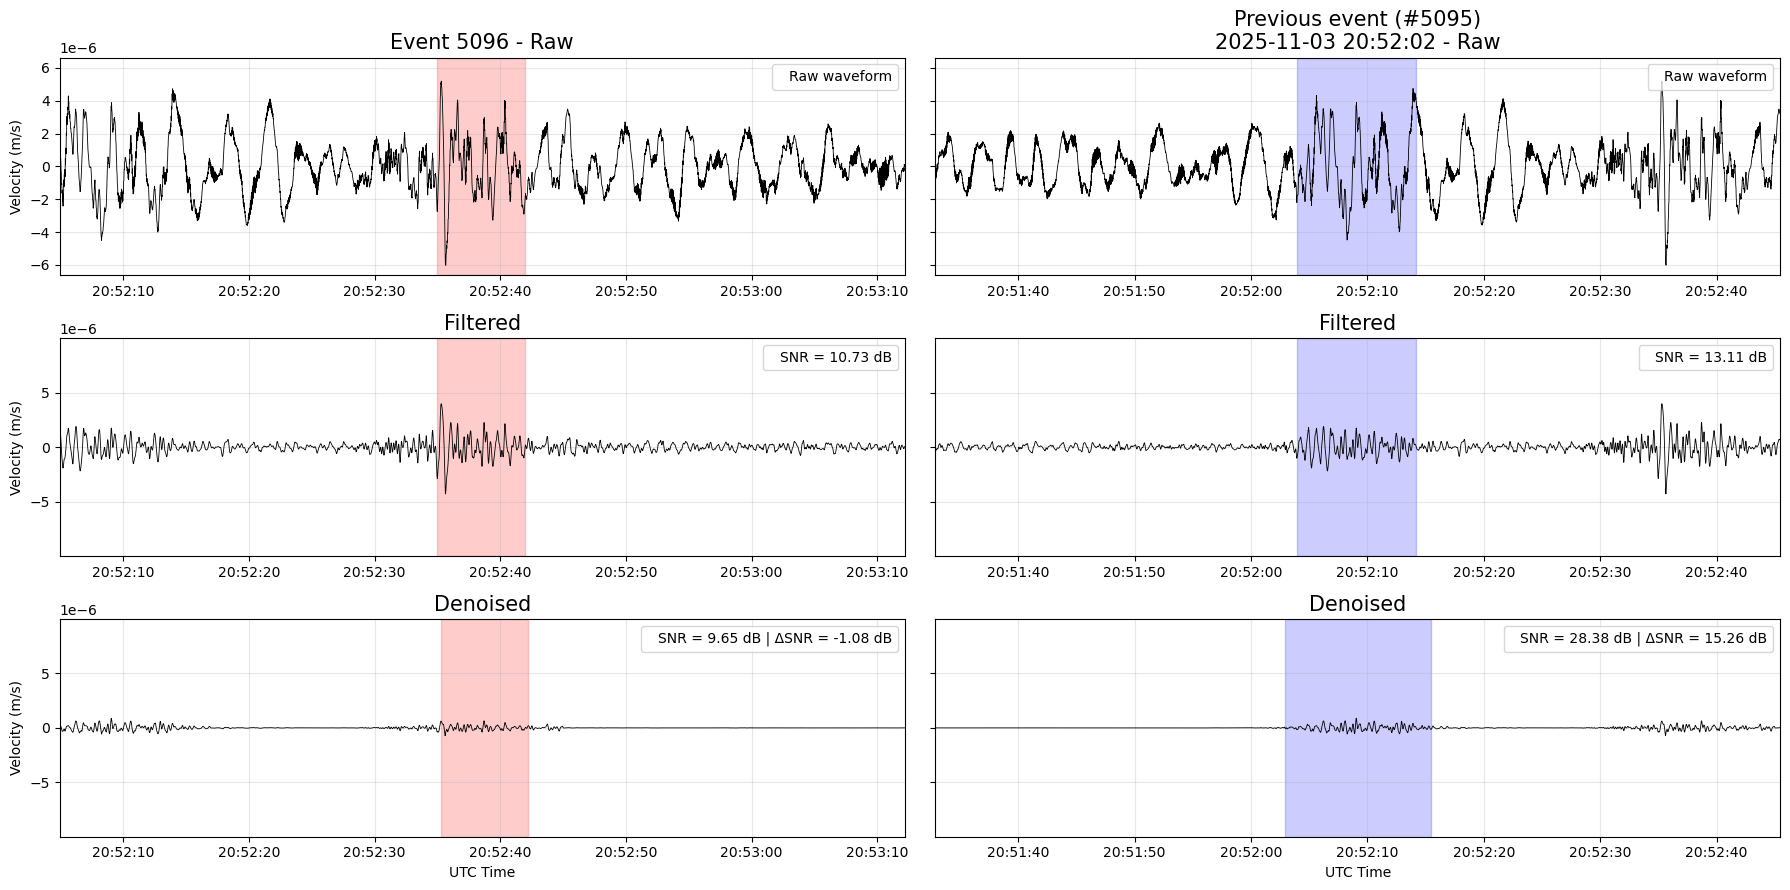


######################################################################
Day 4/7: 2025-11-04T00:00:00.000000Z -> 2025-11-05T00:00:00.000000Z
  2027 events, 3156 detection rows
Skipping 898 event(s) missing a 'filtered' or 'denoised' detection.
Only 120 negative event(s) available; using all of them.

Sample event: 5730
  Sample:   #5730  2025-11-04 02:39:43.800000 -> 2025-11-04 02:40:01.520000
  Previous: #5729  2025-11-04 02:39:13.100000 -> 2025-11-04 02:39:23.260000


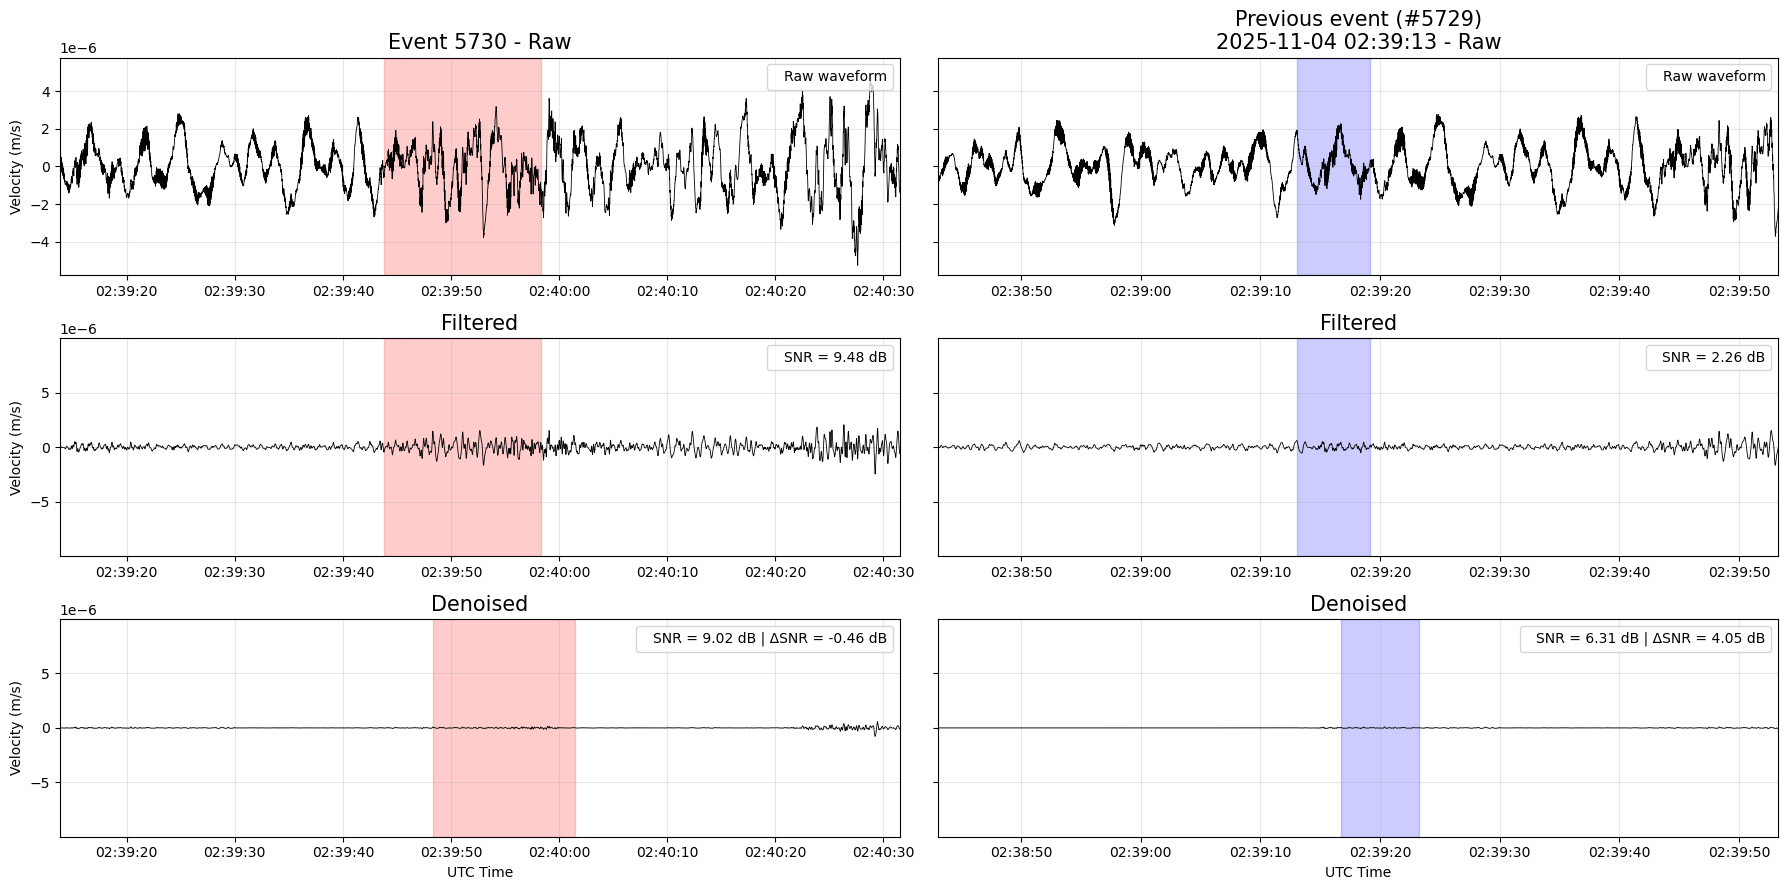


Sample event: 5923
  Sample:   #5923  2025-11-04 05:26:01.160000 -> 2025-11-04 05:26:20.520000
  Previous: #5922  2025-11-04 05:25:41.960000 -> 2025-11-04 05:25:44.120000


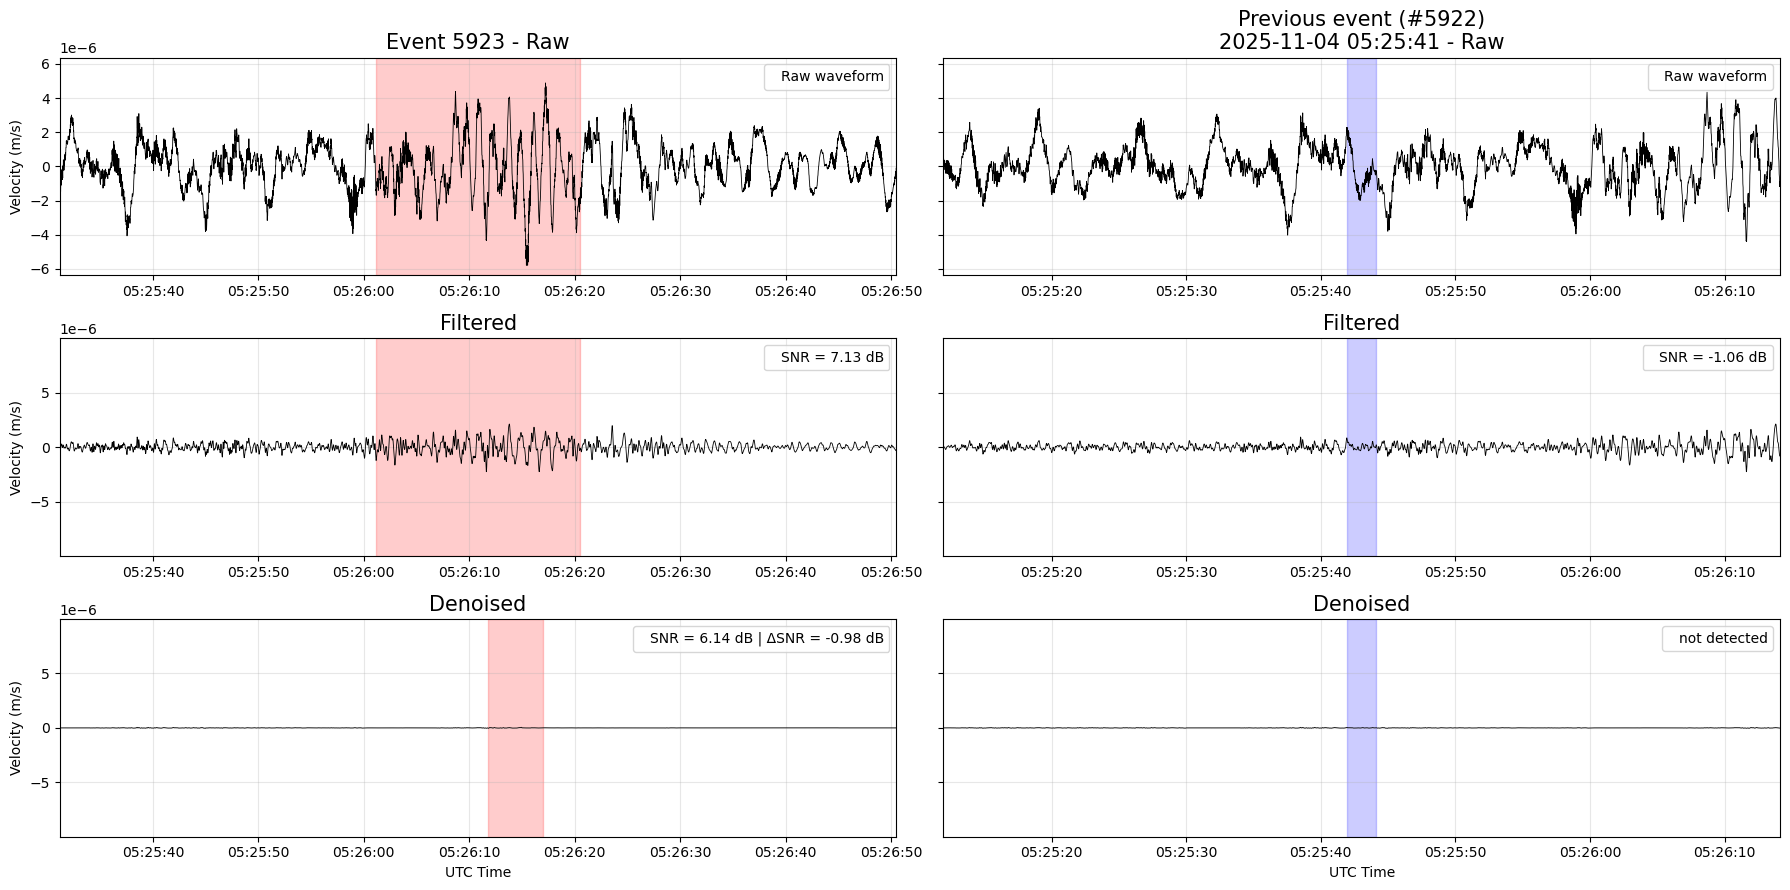


Sample event: 6924
  Sample:   #6924  2025-11-04 19:28:47.160000 -> 2025-11-04 19:29:01.600000
  Previous: #7516  2025-11-04 19:28:14.860000 -> 2025-11-04 19:28:17.040000


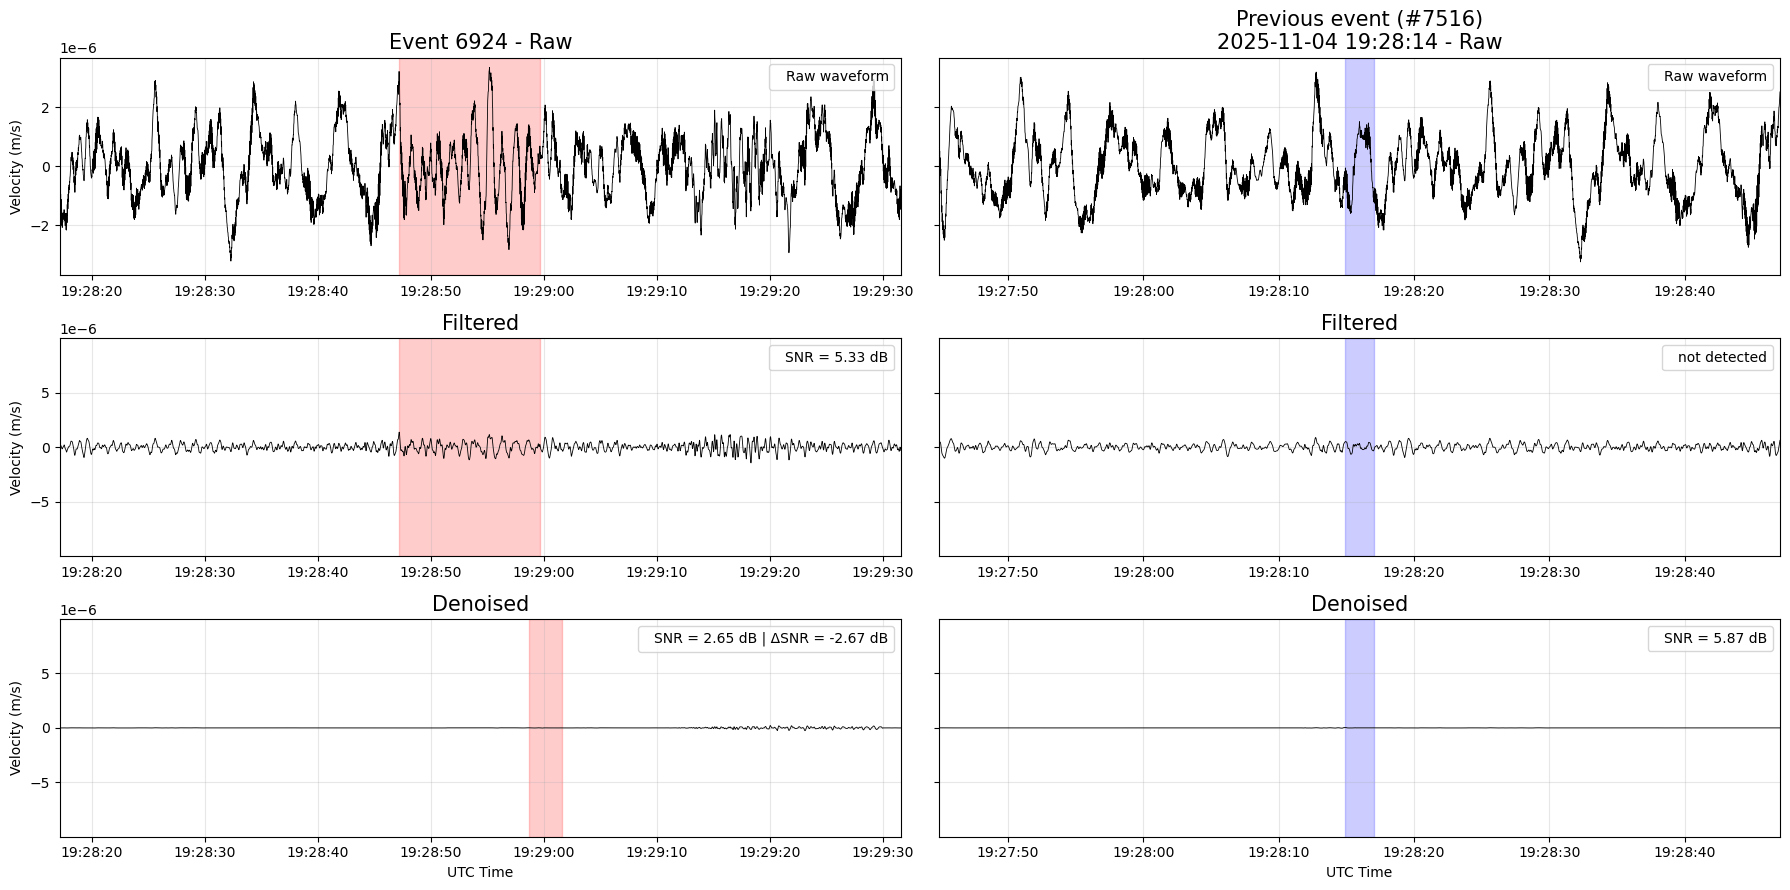


######################################################################
Day 5/7: 2025-11-05T00:00:00.000000Z -> 2025-11-06T00:00:00.000000Z
  2021 events, 3162 detection rows
Skipping 880 event(s) missing a 'filtered' or 'denoised' detection.
Only 124 negative event(s) available; using all of them.

Sample event: 8678
  Sample:   #8678  2025-11-05 15:24:28.660000 -> 2025-11-05 15:24:36.140000
  Previous: #9495  2025-11-05 15:24:06.540000 -> 2025-11-05 15:24:15.560000


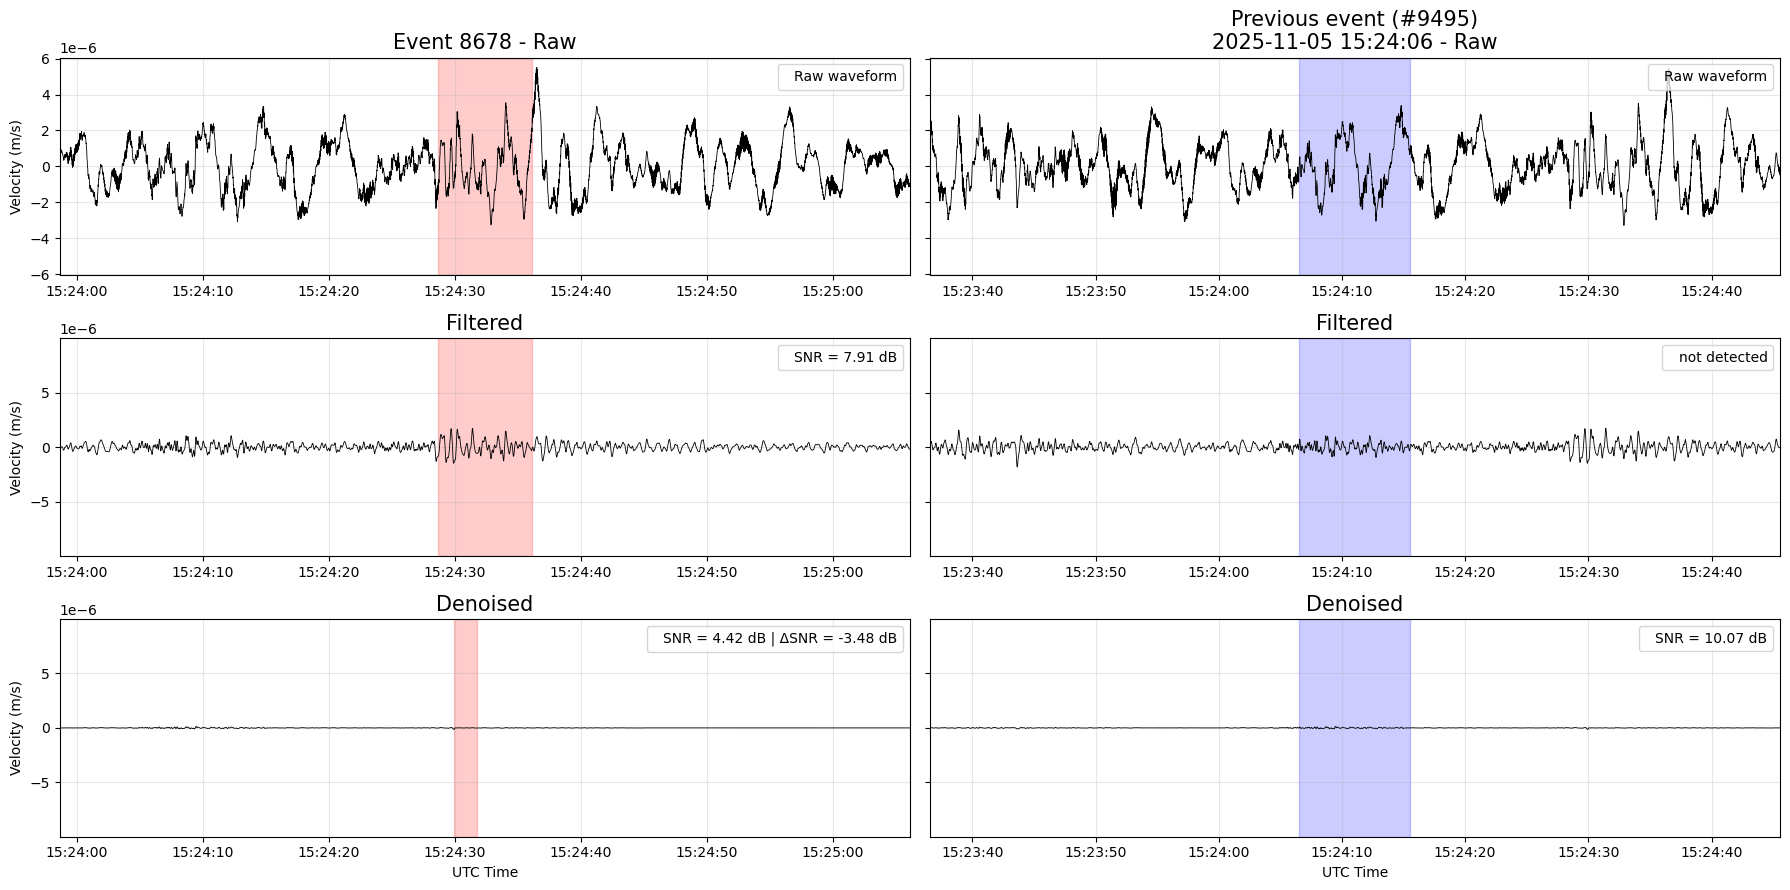


Sample event: 9048
  Sample:   #9048  2025-11-05 20:12:13.260000 -> 2025-11-05 20:12:20.600000
  Previous: #9047  2025-11-05 20:11:18.500000 -> 2025-11-05 20:11:24.740000


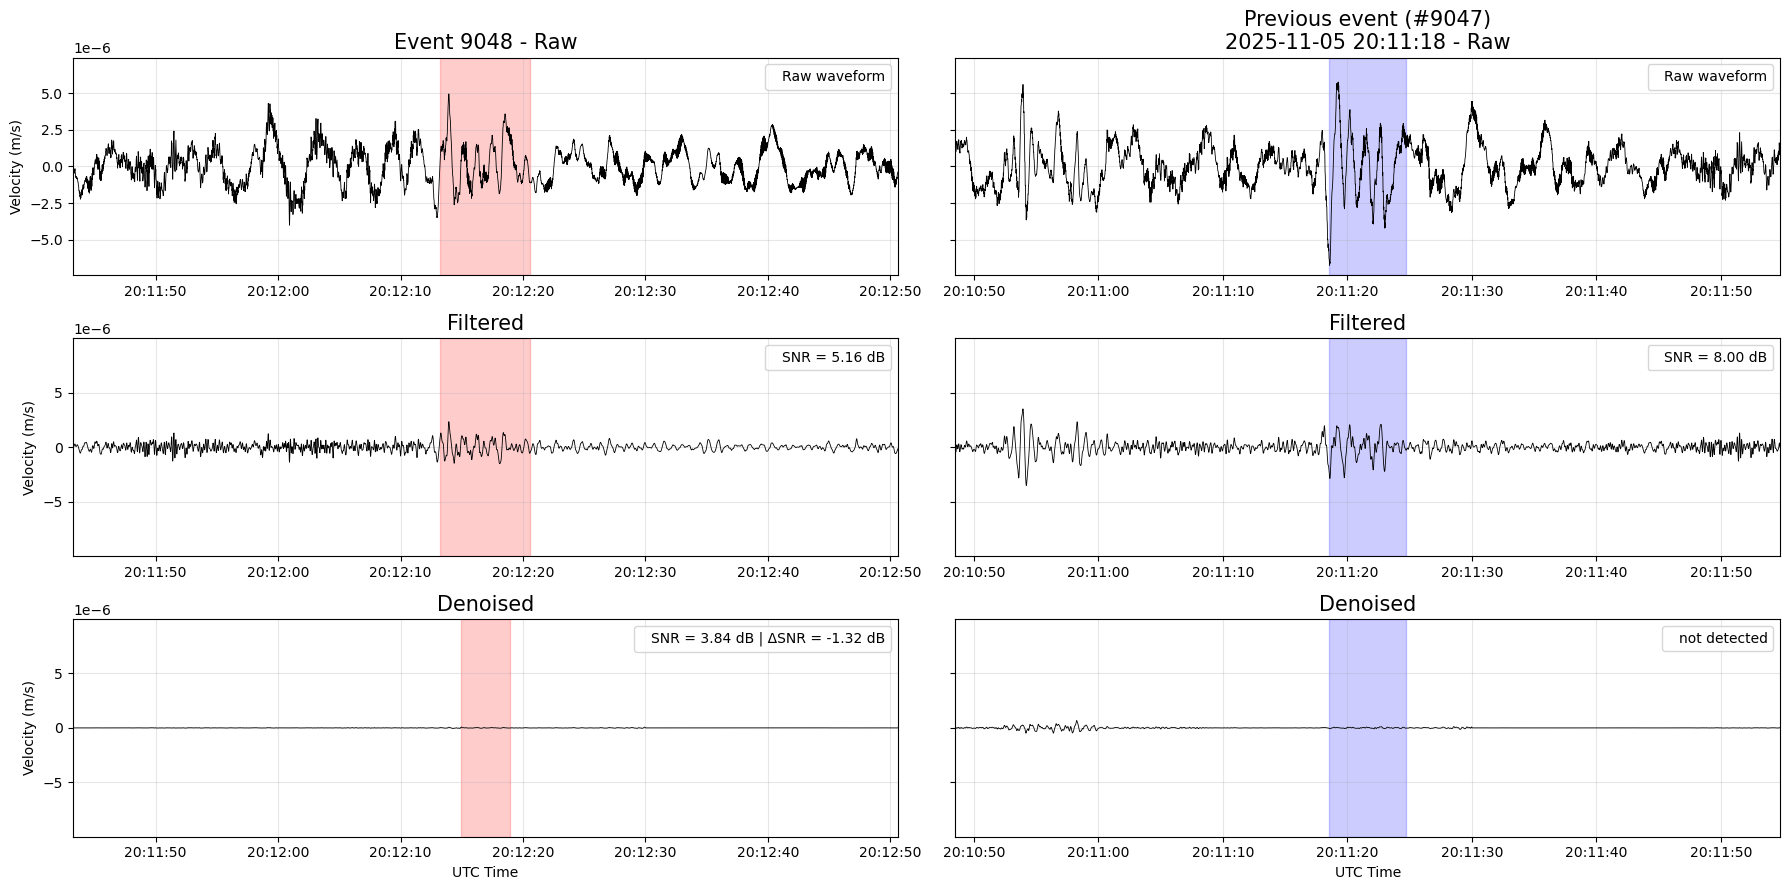


Sample event: 9103
  Sample:   #9103  2025-11-05 21:02:15.880000 -> 2025-11-05 21:02:30.540000
  Previous: #9102  2025-11-05 21:02:05.720000 -> 2025-11-05 21:02:09.480000


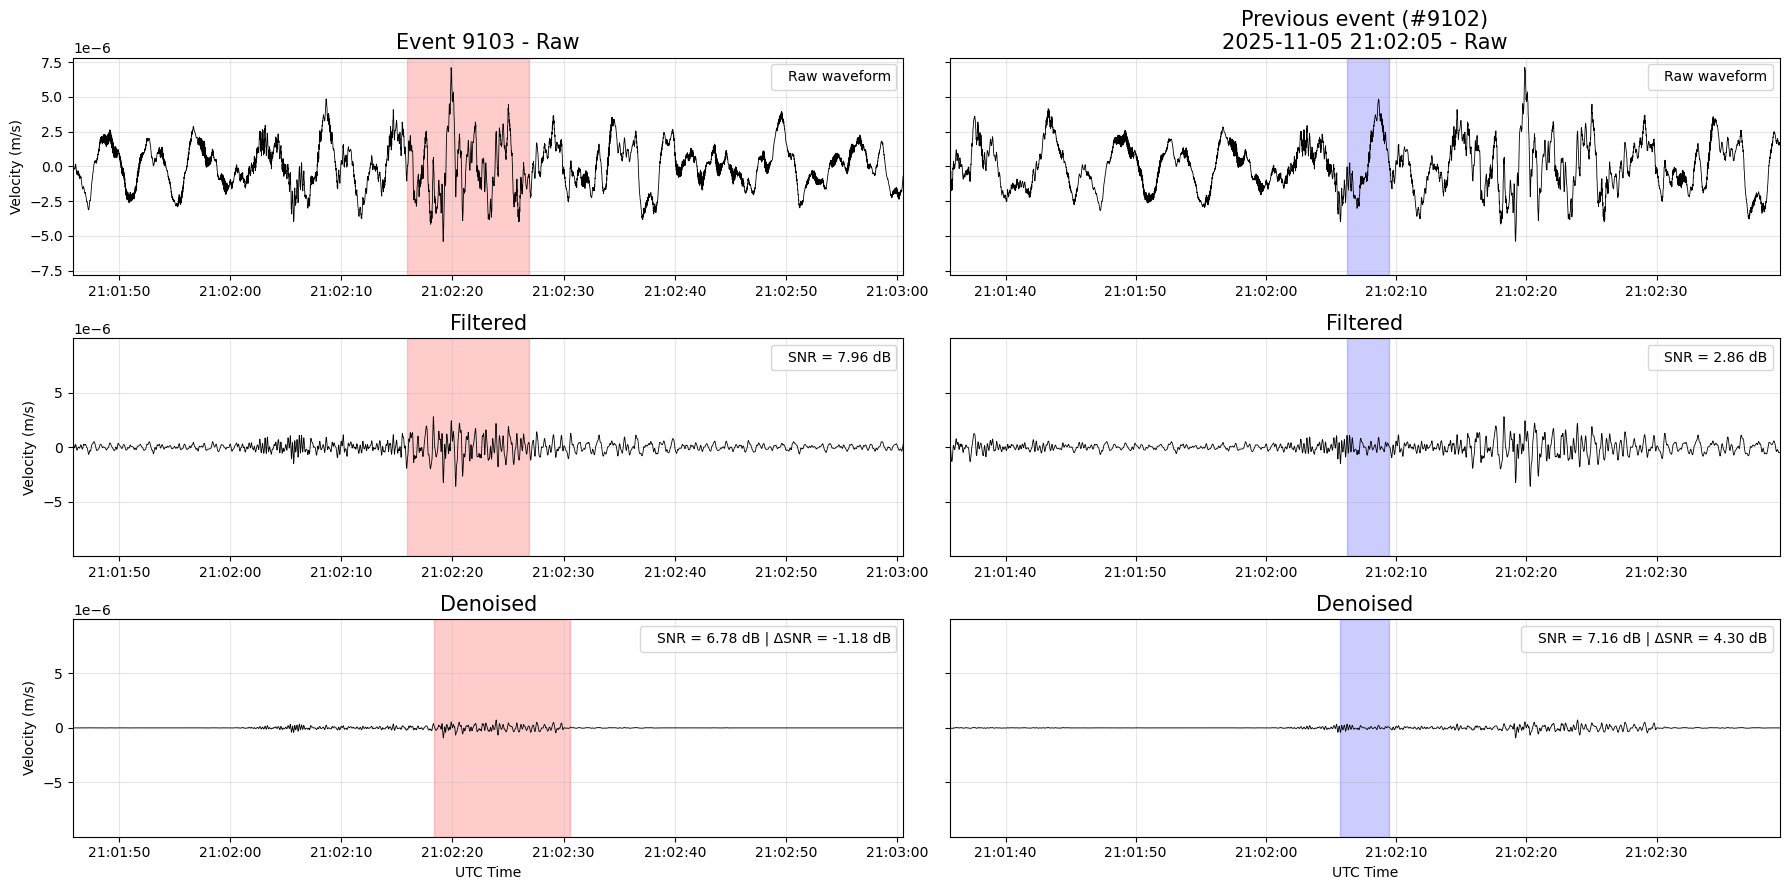


######################################################################
Day 6/7: 2025-11-06T00:00:00.000000Z -> 2025-11-07T00:00:00.000000Z
  1952 events, 3106 detection rows
Skipping 798 event(s) missing a 'filtered' or 'denoised' detection.
Only 119 negative event(s) available; using all of them.

Sample event: 9594
  Sample:   #9594  2025-11-06 00:06:19.840000 -> 2025-11-06 00:06:31.640000
  Previous: #11303  2025-11-06 00:06:12.800000 -> 2025-11-06 00:06:16.960000


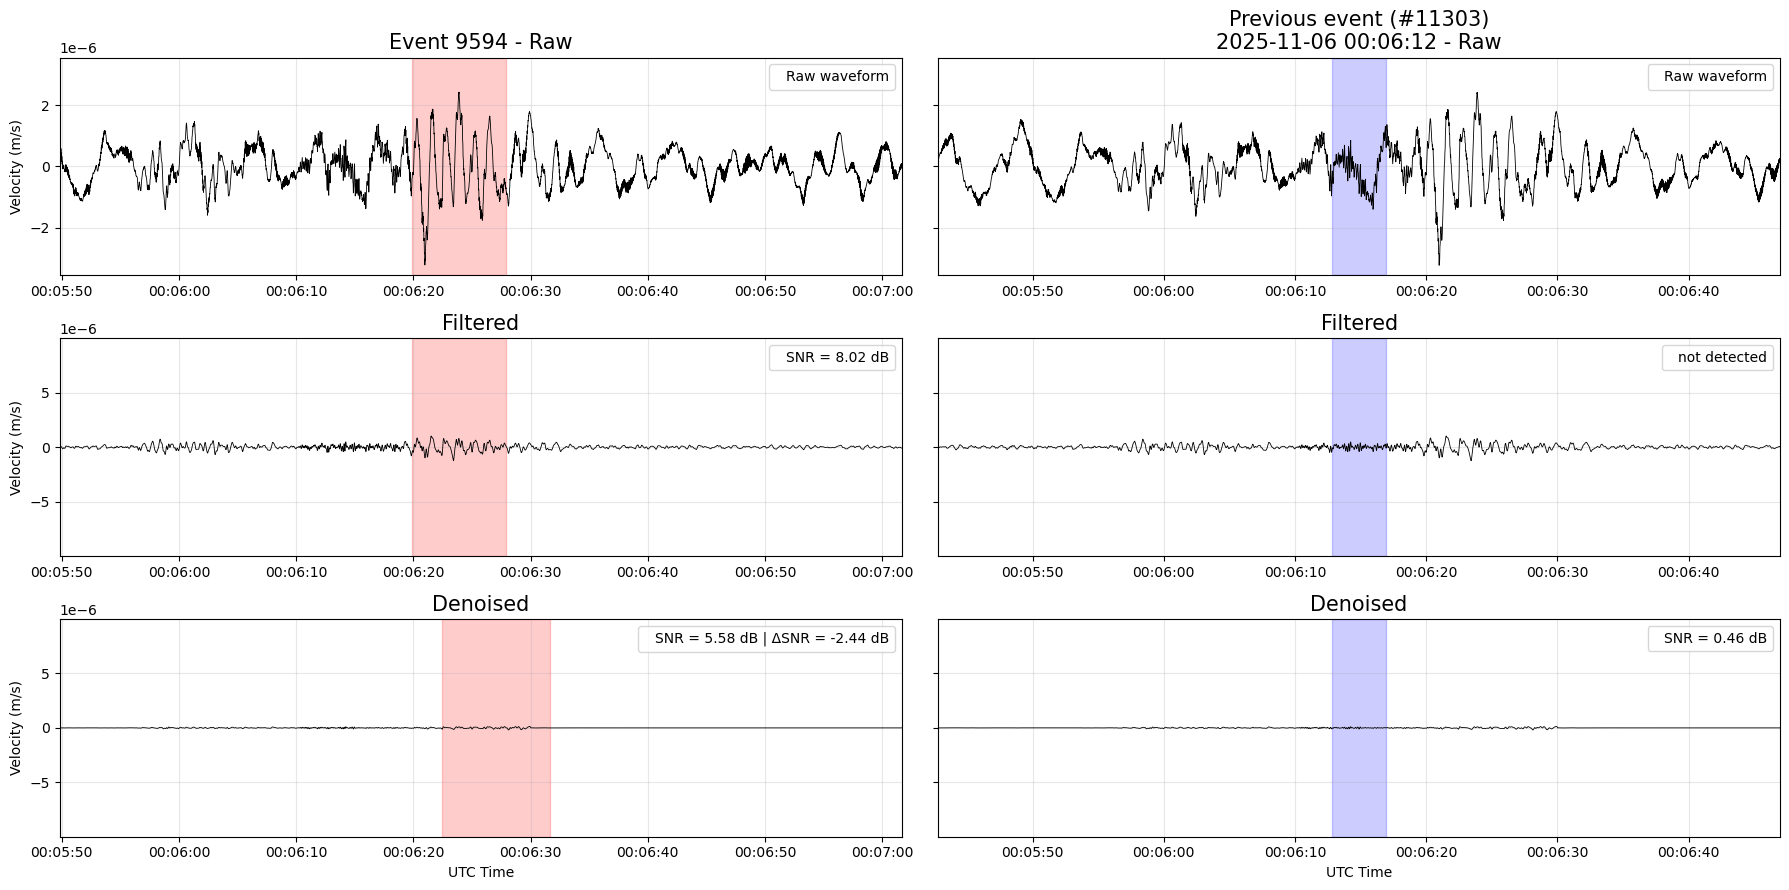


Sample event: 10703
  Sample:   #10703  2025-11-06 15:14:30.840000 -> 2025-11-06 15:14:40.500000
  Previous: #10702  2025-11-06 15:14:06.800000 -> 2025-11-06 15:14:15.680000


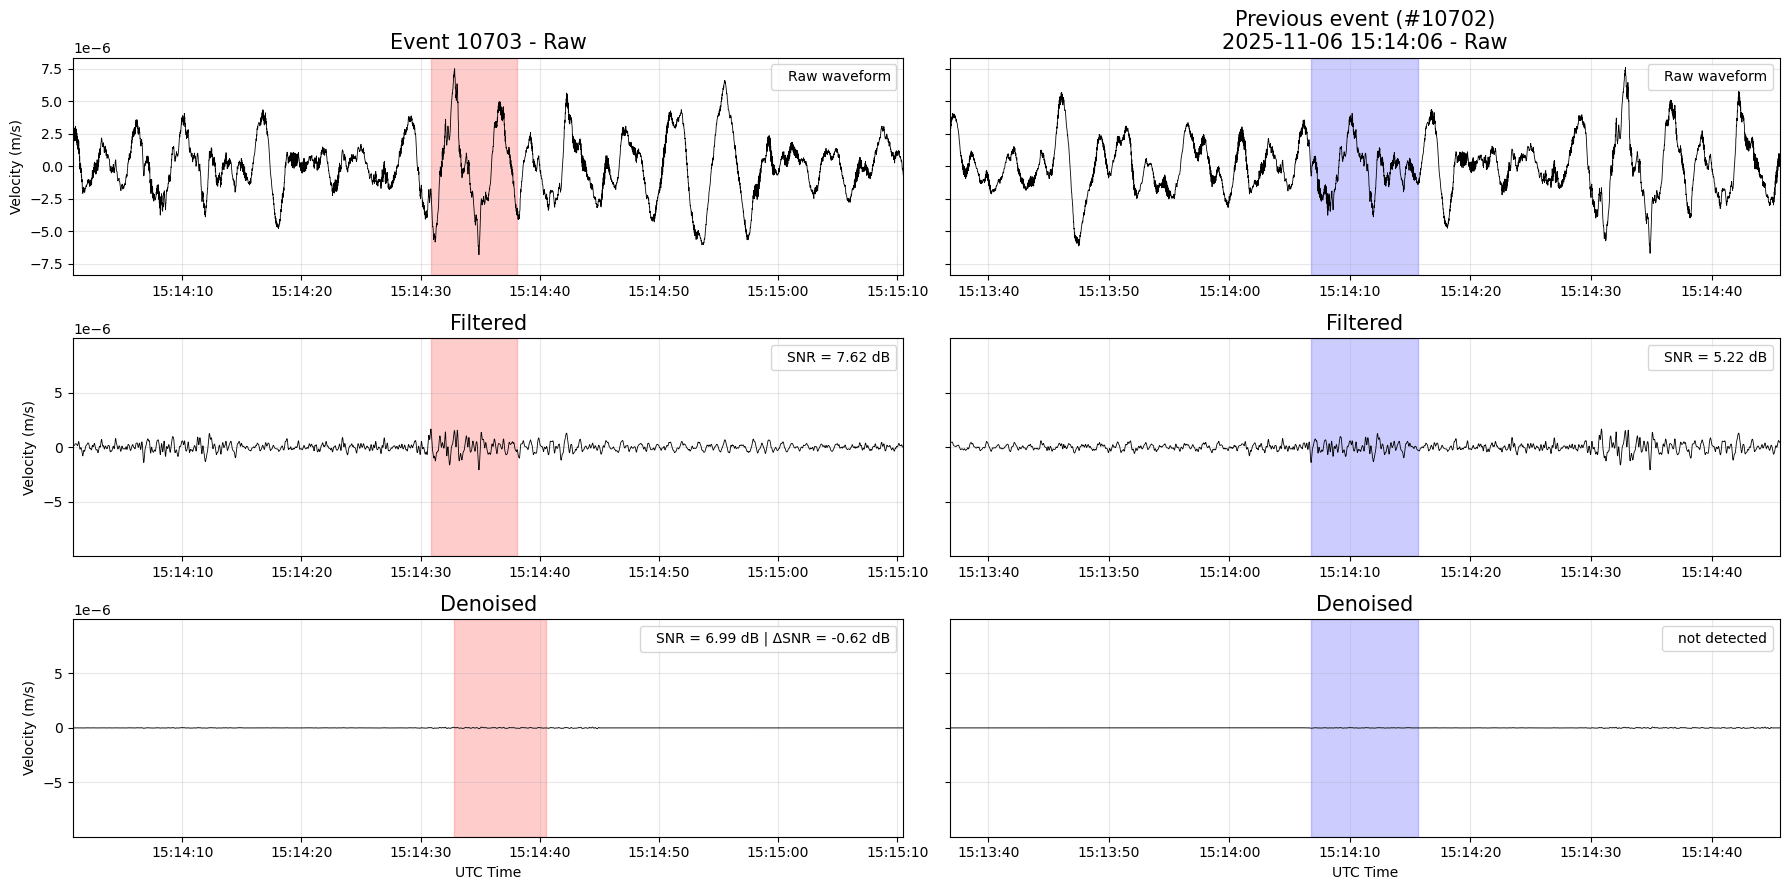


Sample event: 10943
  Sample:   #10943  2025-11-06 18:45:20.140000 -> 2025-11-06 18:45:31.060000
  Previous: #10942  2025-11-06 18:43:02.840000 -> 2025-11-06 18:43:15.380000


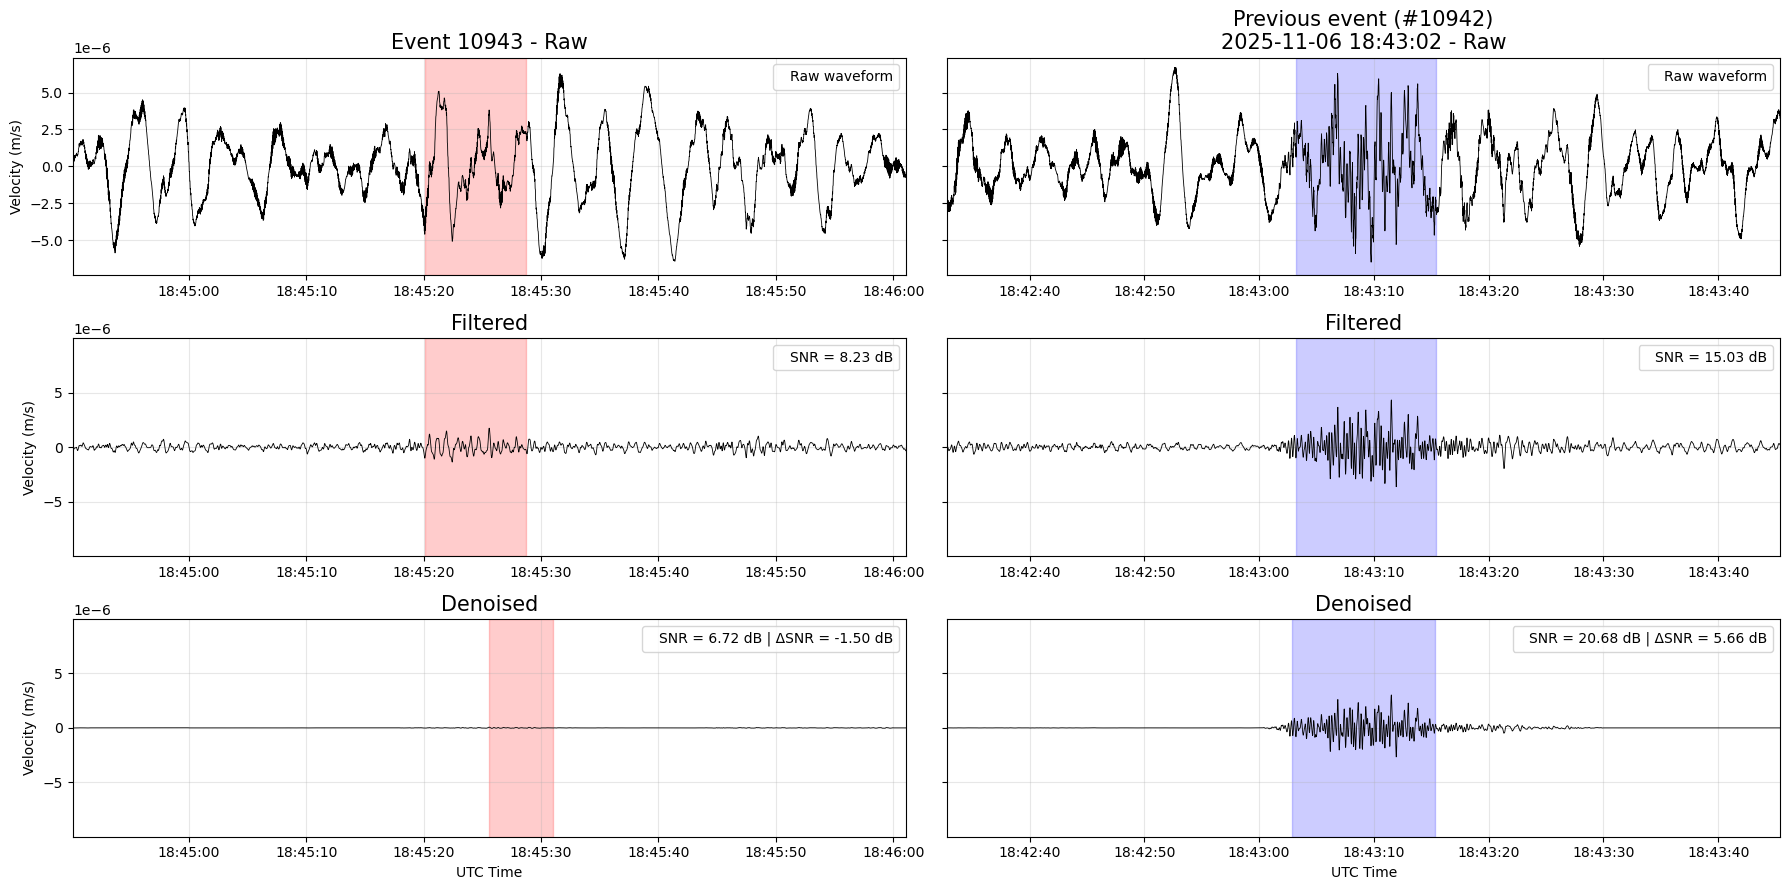


######################################################################
Day 7/7: 2025-11-07T00:00:00.000000Z -> 2025-11-08T00:00:00.000000Z
  2074 events, 3220 detection rows
Skipping 928 event(s) missing a 'filtered' or 'denoised' detection.
Only 115 negative event(s) available; using all of them.

Sample event: 12405
  Sample:   #12405  2025-11-07 11:35:12.980000 -> 2025-11-07 11:35:19.600000
  Previous: #12404  2025-11-07 11:35:04.100000 -> 2025-11-07 11:35:10.820000


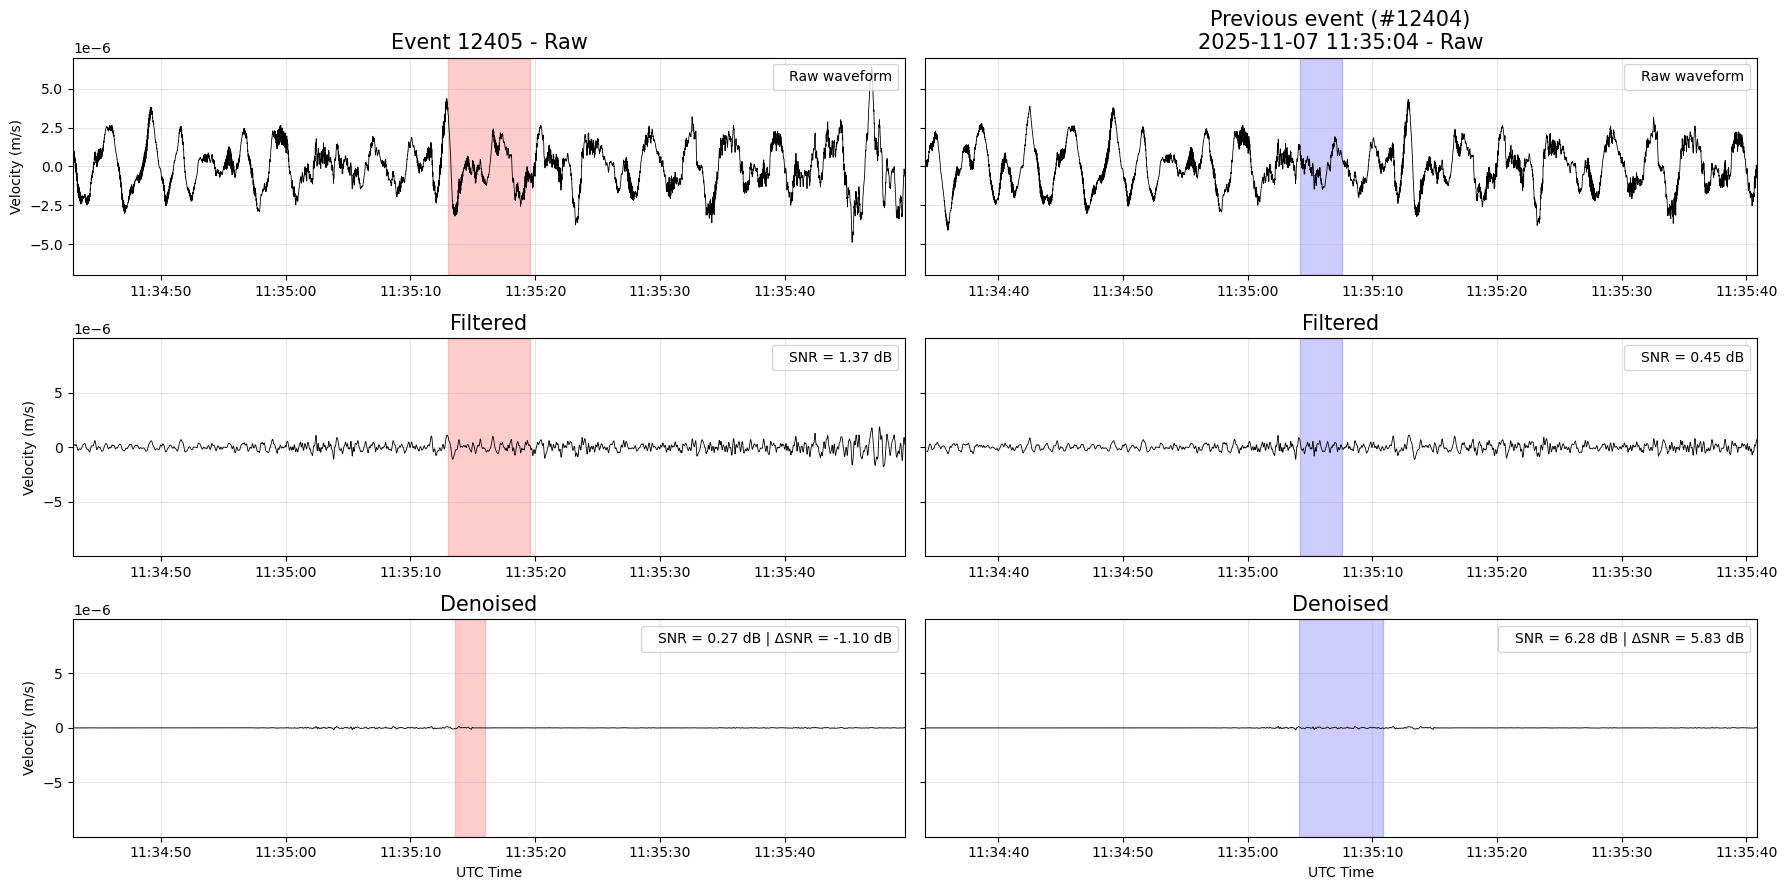


Sample event: 12558
  Sample:   #12558  2025-11-07 13:36:52.780000 -> 2025-11-07 13:37:02.020000
  Previous: #12557  2025-11-07 13:36:06.420000 -> 2025-11-07 13:36:16.860000


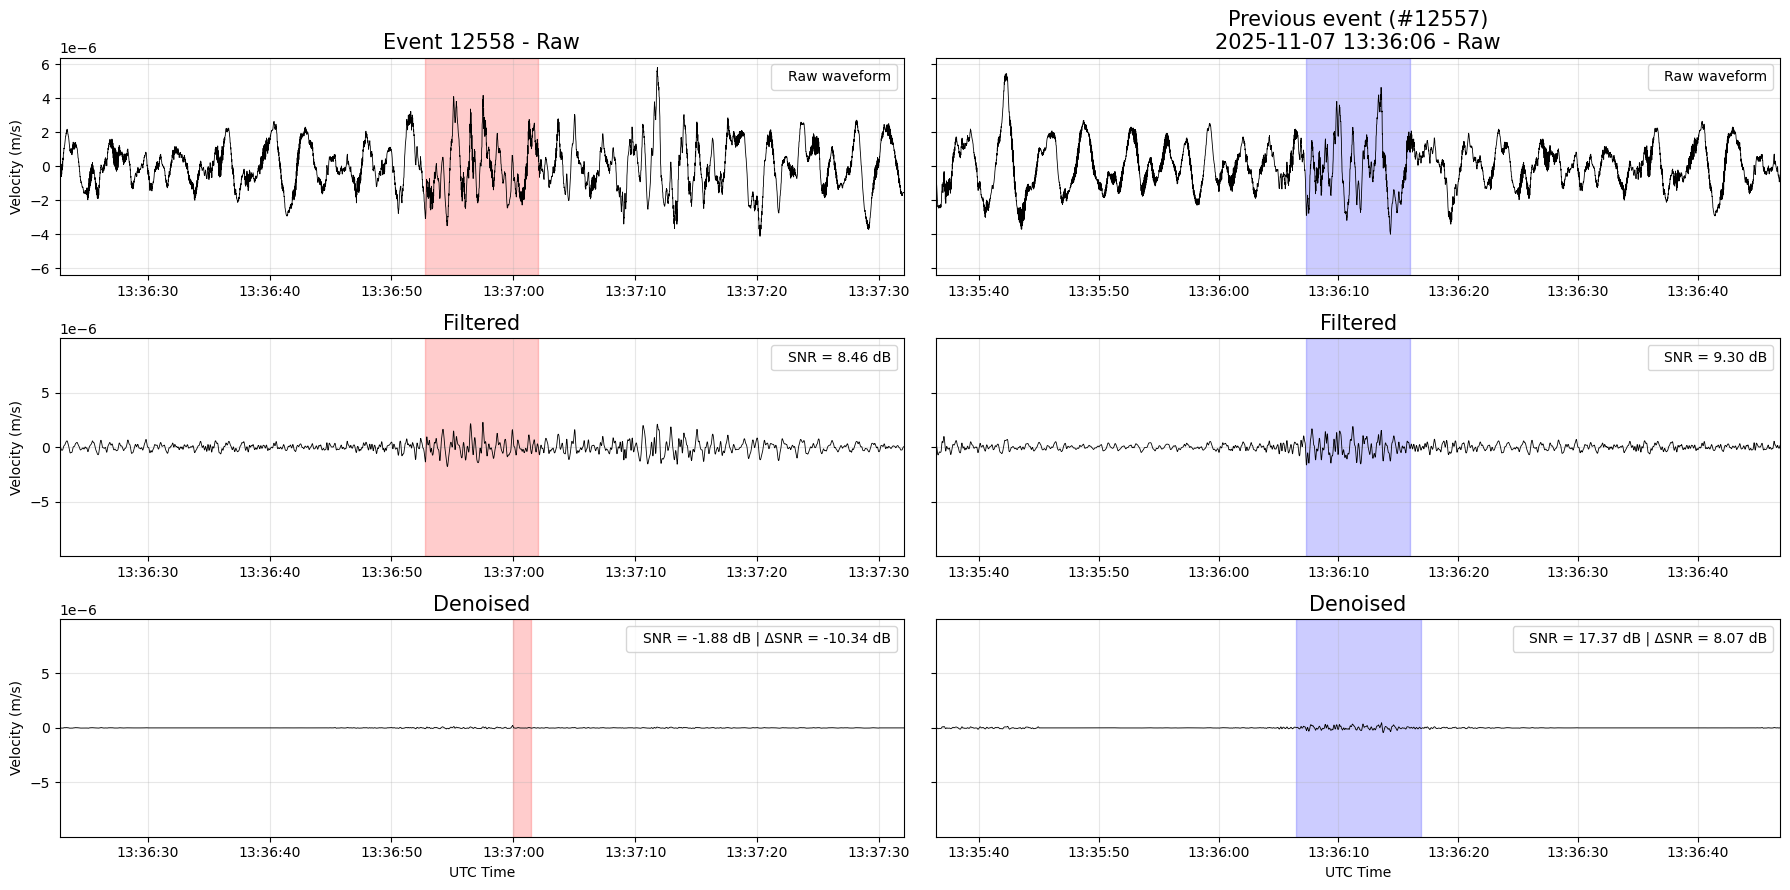


Sample event: 12575
  Sample:   #12575  2025-11-07 13:49:37.540000 -> 2025-11-07 13:49:46.560000
  Previous: #12574  2025-11-07 13:49:29.460000 -> 2025-11-07 13:49:33


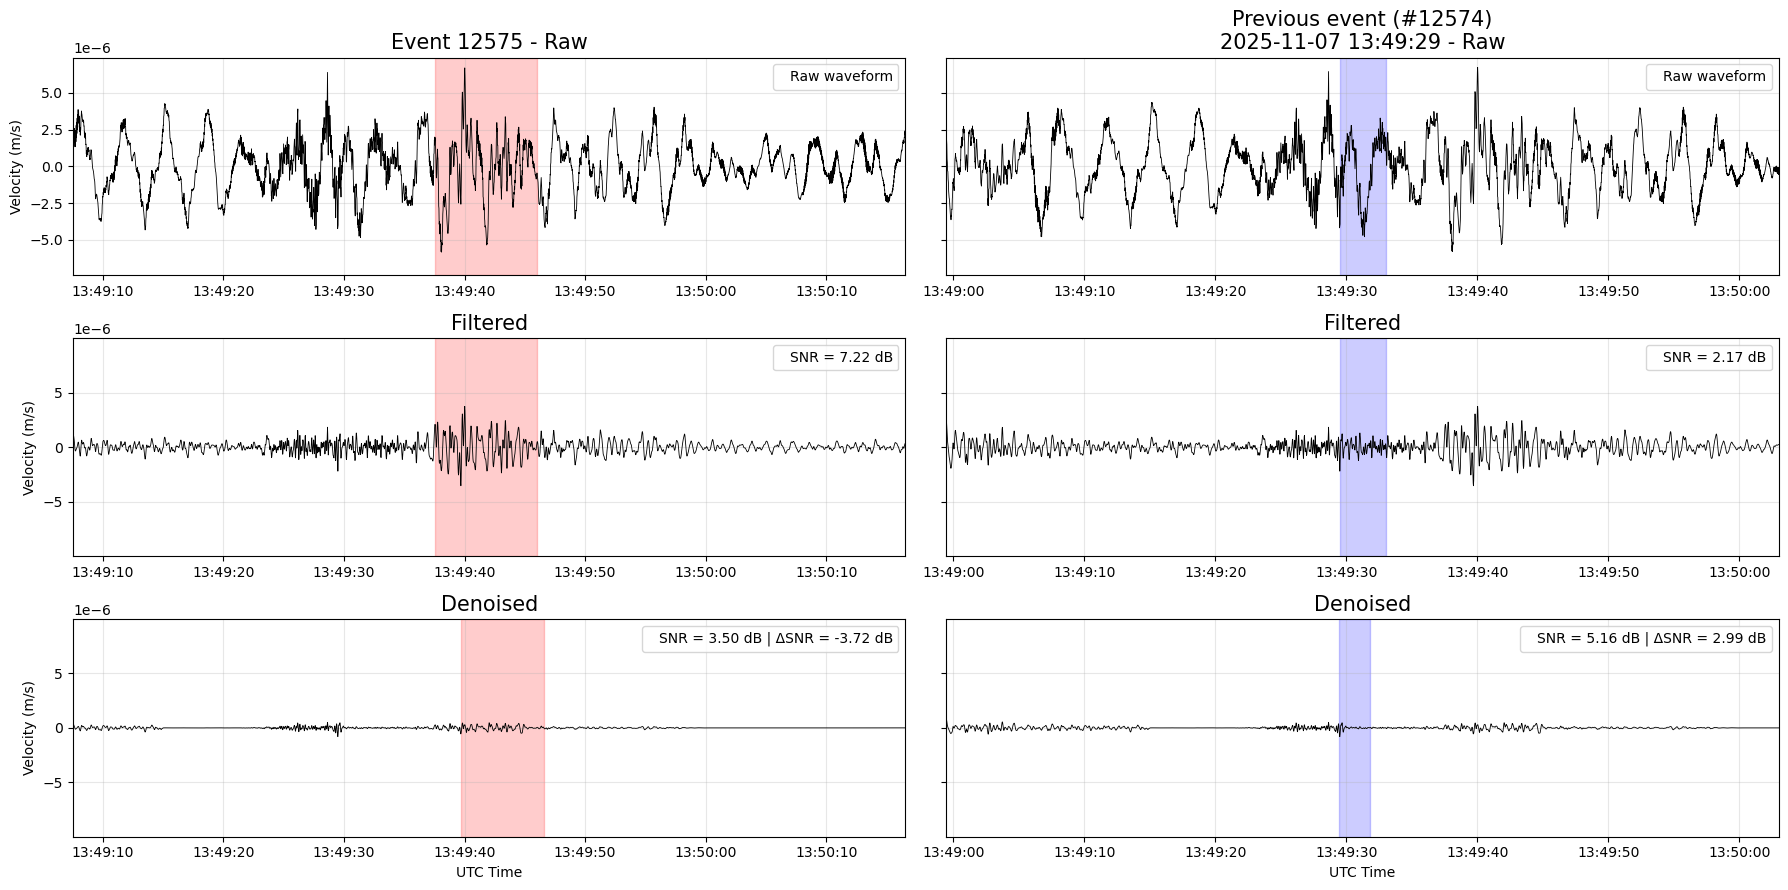


Done.


In [145]:
from shishaldin_snr_comparison import matched_snr_differences
from shishaldin_snr_diagnostics import select_random_negative_events

os.makedirs(OUTPUT_DIR, exist_ok=True)
week_catalog_file = f"{OUTPUT_DIR}/shishaldin_catalog_week.csv"

day_catalogs = []
failed_days = []
next_event_number = 1

for d in range(N_DAYS):
    day_start = WEEK_START + d * WINDOW_HOURS * 3600
    day_end = day_start + WINDOW_HOURS * 3600
    label = day_start.strftime("%Y-%m-%d")
    day_csv = f"{OUTPUT_DIR}/catalog_{label}.csv"

    print("\n" + "#" * 70)
    print(f"Day {d + 1}/{N_DAYS}: {day_start} -> {day_end}")

    # resume support: if this day was already processed, reuse its catalog (no plots)
    if os.path.exists(day_csv):
        print(f"  {day_csv} exists, loading instead of reprocessing.")
        day_df = pd.read_csv(day_csv)
        day_catalogs.append(day_df)
        if len(day_df):
            next_event_number = int(day_df["event_number"].max()) + 1
        continue

    try:
        day_df, day_waveforms = process_window(day_start, day_end, next_event_number)
    except Exception as exc:
        print(f"  {label} failed: {exc}")
        failed_days.append(label)
        continue

    day_df.to_csv(day_csv, index=False)
    day_catalogs.append(day_df)
    if len(day_df):
        next_event_number = int(day_df["event_number"].max()) + 1

    # cumulative weekly CSV, so "previous event" lookups work across day boundaries
    pd.concat(day_catalogs, ignore_index=True).to_csv(week_catalog_file, index=False)

    print(f"  {day_df['event_number'].nunique()} events, {len(day_df)} detection rows")

    # plot this day's negative-SNR events vs. the event before each one
    if PLOT_PER_DAY and len(day_df):
        try:
            day_cat = day_df.copy()
            day_cat["start_time"] = pd.to_datetime(day_cat["start_time"])
            day_cat["end_time"] = pd.to_datetime(day_cat["end_time"])

            day_differences = matched_snr_differences(day_cat)
            sample = select_random_negative_events(day_differences, n=N_NEGATIVE_PER_DAY, seed=d)

            figs = plot_sample_events(
                sample, day_waveforms,
                catalog_file=week_catalog_file,
                event_padding_seconds=30,
            )
            for fig in figs:
                plt.close(fig)
        except Exception as exc:
            print(f"  plotting for {label} failed: {exc}")

    # free this day's waveforms before loading the next
    del day_waveforms
    gc.collect()

print("\nDone.")
if failed_days:
    print(f"Failed days (rerun the cell to retry them): {failed_days}")

Skipping 5516 event(s) missing a 'filtered' or 'denoised' detection.
Mean SNR improvement: 10.22 ± 8.28 dB over 8094 matched events


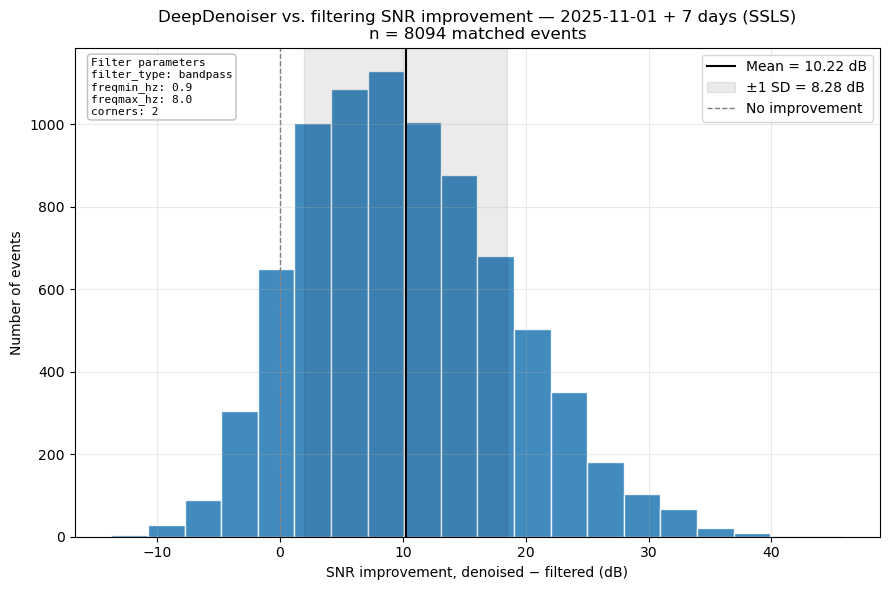

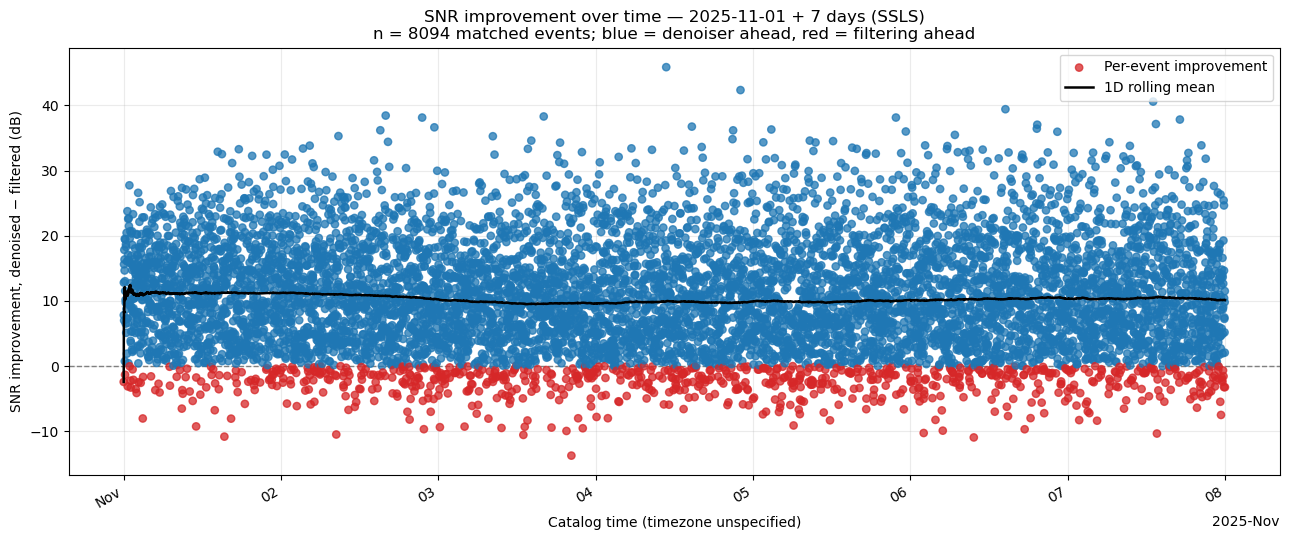

In [146]:
from shishaldin_snr_comparison import (
    matched_snr_differences, plot_snr_difference_histogram, plot_snr_difference_timeseries,
)

week_catalog = pd.concat(day_catalogs, ignore_index=True)
week_catalog["start_time"] = pd.to_datetime(week_catalog["start_time"])
week_catalog["end_time"] = pd.to_datetime(week_catalog["end_time"])

differences_week = matched_snr_differences(week_catalog)

filter_params = {
    "filter_type": "bandpass",
    "freqmin_hz": FREQMIN,
    "freqmax_hz": FREQMAX,
    "corners": CORNERS,
}

sheet_week = f"{WEEK_START.date} + {N_DAYS} days ({STATION})"

fig_hist, mean_diff, std_diff = plot_snr_difference_histogram(
    differences_week, sheet_week, filter_params=filter_params)
fig_ts = plot_snr_difference_timeseries(differences_week, sheet_week)

print(f"Mean SNR improvement: {mean_diff:.2f} \u00b1 {std_diff:.2f} dB "
      f"over {len(differences_week)} matched events")

In [147]:
positive = (differences_week['snr_difference_db'] > 0).sum()
negative = (differences_week['snr_difference_db'] < 0).sum()
zero = (differences_week['snr_difference_db'] == 0).sum()

ratio = positive / negative if negative > 0 else float('inf')

print(f'Positive (denoiser ahead): {positive}')
print(f'Negative (filtering ahead): {negative}')
print(f'Zero (tied): {zero}')
print(f'Positive:negative ratio = {ratio:.2f} : 1' if negative > 0
      else 'Positive:negative ratio = undefined (no negative differences)')

total = len(differences_week)
print(f'{positive / total:.1%} favored the denoiser, {negative / total:.1%} favored filtering')

Positive (denoiser ahead): 7307
Negative (filtering ahead): 787
Zero (tied): 0
Positive:negative ratio = 9.28 : 1
90.3% favored the denoiser, 9.7% favored filtering


## Appendix -- explore a previously-exported multi-day catalog (optional)

This is the original xlsx-workbook-based path from `plot.ipynb`, for
browsing a catalog you already exported across multiple days/sheets,
rather than the single window built in Part 1 above. It's independent of
everything above -- delete this section if you don't use that workflow.

In [ ]:
from pathlib import Path
from shishaldin_catalog_explorer import load_catalogs, CatalogExplorer

CATALOG_PATH = '/Users/amelega/Desktop/figures/Longer period Shishaldin Event Detection (hours).xlsx'
APPENDIX_SHEET = '24 hours'
APPENDIX_EVENT_PADDING_SECONDS = 30

%matplotlib ipympl

appendix_catalogs = load_catalogs(CATALOG_PATH)
print({name: len(frame) for name, frame in appendix_catalogs.items()})

appendix_explorer = CatalogExplorer(appendix_catalogs, APPENDIX_SHEET, APPENDIX_EVENT_PADDING_SECONDS)
appendix_explorer.fig.canvas